# CIFAR-10 CNN Architecture Design

This notebook focuses on architectural choices: baseline CNNs, back-to-back convolutions,
mirrored data, network size, kernel size, strided convolution, and increased depth.
Alternative configurations are retained when they change filters, dense-layer width, training
duration, or optimizer behavior.

## Back-to-Back Convolutions and Mirrored Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.losses import *
from tensorflow.keras.activations import *
from keras.utils import plot_model
import cv2 as cv

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error

import time

In [2]:
def plot_results(history):
  fig, ax = plt.subplots(ncols=2, figsize=(12,4))
  ax[0].plot(history.history['accuracy'],label = 'train')
  ax[0].plot(history.history['val_accuracy'],label = 'test')
  ax[0].set_title('Accuracy')
  ax[0].legend(loc='lower right')
  ax[1].plot(history.history['loss'],label = 'train')
  ax[1].plot(history.history['val_loss'],label = 'test')
  ax[1].set_title('Loss')
  ax[1].legend(loc='upper right')
  plt.show()

def print_best_metrics(h):
  labels = ['training accuracy', 'validation accuracy', 'training loss', 'validation loss']
  keys = ['accuracy', 'val_accuracy', 'loss', 'val_loss']
  prefix = ['highest','lowest']
  for i in range(4):
    metric = np.array(h[keys[i]])
    am = np.argmax((1.5-i)*metric)
    print(f'The {prefix[i//2]} {labels[i]} was {metric[am]:.4f} obtained in epoch {am+1}')
    print(f'The final {labels[i]} was {metric[-1]:.4f}')

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Convert from uint8 to float and scale in [0,1] range
x_train = np.float32(x_train/255.0)
x_test = np.float32(x_test/255.0)
label = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# Convert y to one-hot
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print('Final shapes')
print(f'{x_train.shape = }')
print(f'{y_train.shape = }')
print(f'{x_test.shape = }')
print(f'{y_test.shape = }')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2097s 12us/step
Final shapes
x_train.shape = (50000, 32, 32, 3)
y_train.shape = (50000, 10)
x_test.shape = (10000, 32, 32, 3)
y_test.shape = (10000, 10)


Let's see some of the images in the dataset and their mirrored versions:

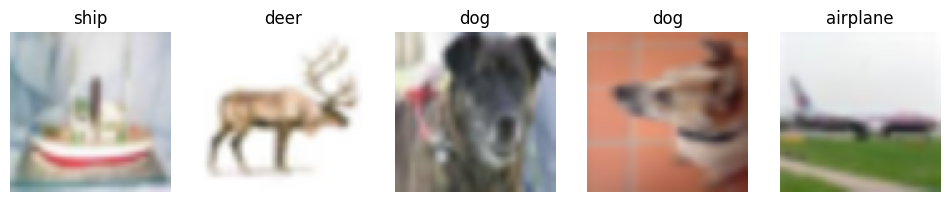

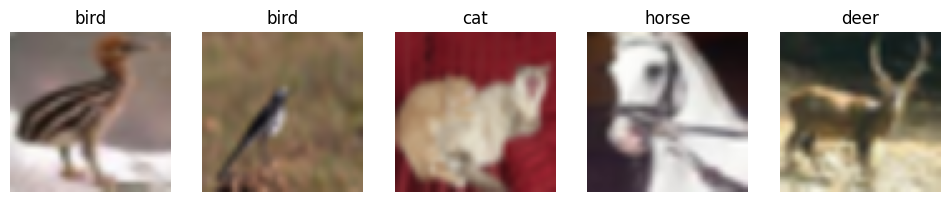

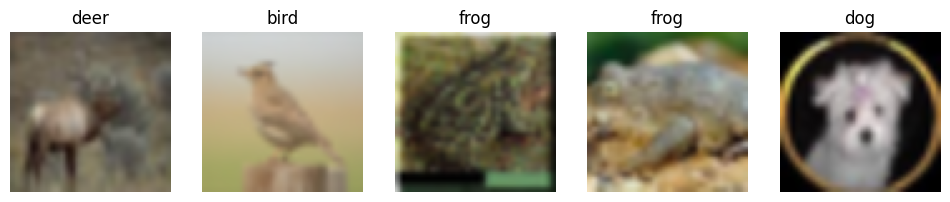

In [4]:
np.random.seed(0)
for k in range(3):
  sel = np.random.randint(0,x_train.shape[0],size = 5)
  k = 2
  fig, ax = plt.subplots(nrows=1,ncols=len(sel), figsize=(12,4))
  for i,s in enumerate(sel):
    ax[i].imshow(cv.resize(x_train[s], (32*k, 32*k)))
    ax[i].set_title(label[np.argmax(y_train[s])])
    ax[i].set_axis_off()

## Baseline CNN

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,730 (424.73 KB)

 Trainable params: 108,730 (424.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
500/500 - 11s - 21ms/step - accuracy: 0.4036 - loss: 1.6411 - val_accuracy: 0.5001 - val_loss: 1.4218
Epoch 2/20
500/500 - 2s - 3ms/step - accuracy: 0.5595 - loss: 1.2352 - val_accuracy: 0.5931 - val_loss: 1.1708
Epoch 3/20
500/500 - 2s - 3ms/step - accuracy: 0.6272 - loss: 1.0608 - val_accuracy: 0.6468 - val_loss: 1.0184
Epoch 4/20
500/500 - 2s - 3ms/step - accuracy: 0.6692 - loss: 0.9481 - val_accuracy: 0.6650 - val_loss: 0.9527
Epoch 5/20
500/500 - 2s - 3ms/step - accuracy: 0.6946 - loss: 0.8741 - val_accuracy: 0.6860 - val_loss: 0.9165
Epoch 6/20
500/500 - 2s - 3ms/step - accuracy: 0.7146 - loss: 0.8191 - val_accuracy: 0.6919 - val_loss: 0.8808
Epoch 7/20
500/500 - 2s - 3ms/step - accuracy: 0.7345 - loss: 0.7712 - val_accuracy: 0.7097 - val_loss: 0.8497
Epoch 8/20
500/500 - 2s - 3ms/step - accuracy: 0.7484 - loss: 0.7273 - val_accuracy: 0.7200 - val_loss: 0.8189
Epoch 9/20
500/500 - 2s - 3ms/step - accuracy: 0.7590 - loss: 0.6900 - val_accuracy: 0.7041 - val_loss: 0.8844

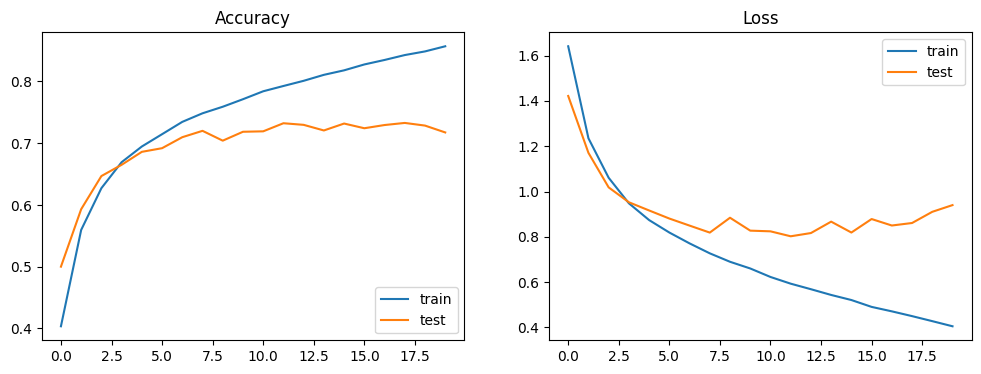

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
Elapsed time training= 42.7715 secs
Mean squared error = 0.041
Accuracy = 0.7174
The highest training accuracy was 0.8569 obtained in epoch 20
The final training accuracy was 0.8569
The highest validation accuracy was 0.7328 obtained in epoch 18
The final validation accuracy was 0.7174
The lowest training loss was 0.4054 obtained in epoch 20
The final training loss was 0.4054
The lowest validation loss was 0.8025 obtained in epoch 12
The final validation loss was 0.9402


In [5]:
def cnn(input_shape, conv_units,dense_units):
  model = tf.keras.Sequential()
  model.add(Input(shape=input_shape))
  for c in conv_units:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(dense_units, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn(x_train.shape[1:],[32,48,64],64)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 20,
    batch_size = 100,
    verbose = 2,
    validation_data=(x_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))
print_best_metrics(history.history)

## Back-to-Back Convolutional Layers

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,690 (686.29 KB)

 Trainable params: 175,690 (686.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
500/500 - 8s - 17ms/step - accuracy: 0.3963 - loss: 1.6478 - val_accuracy: 0.5331 - val_loss: 1.2951
Epoch 2/20
500/500 - 2s - 4ms/step - accuracy: 0.5853 - loss: 1.1581 - val_accuracy: 0.6370 - val_loss: 1.0122
Epoch 3/20
500/500 - 2s - 4ms/step - accuracy: 0.6697 - loss: 0.9340 - val_accuracy: 0.6659 - val_loss: 0.9517
Epoch 4/20
500/500 - 2s - 4ms/step - accuracy: 0.7203 - loss: 0.7963 - val_accuracy: 0.7033 - val_loss: 0.8696
Epoch 5/20
500/500 - 2s - 4ms/step - accuracy: 0.7562 - loss: 0.6980 - val_accuracy: 0.7356 - val_loss: 0.7618
Epoch 6/20
500/500 - 2s - 4ms/step - accuracy: 0.7864 - loss: 0.6154 - val_accuracy: 0.7411 - val_loss: 0.7430
Epoch 7/20
500/500 - 2s - 4ms/step - accuracy: 0.8050 - loss: 0.5550 - val_accuracy: 0.7448 - val_loss: 0.7396
Epoch 8/20
500/500 - 2s - 4ms/step - accuracy: 0.8231 - loss: 0.5054 - val_accuracy: 0.7523 - val_loss: 0.7348
Epoch 9/20
500/500 - 2s - 4ms/step - accuracy: 0.8399 - loss: 0.4576 - val_accuracy: 0.7667 - val_loss: 0.7035


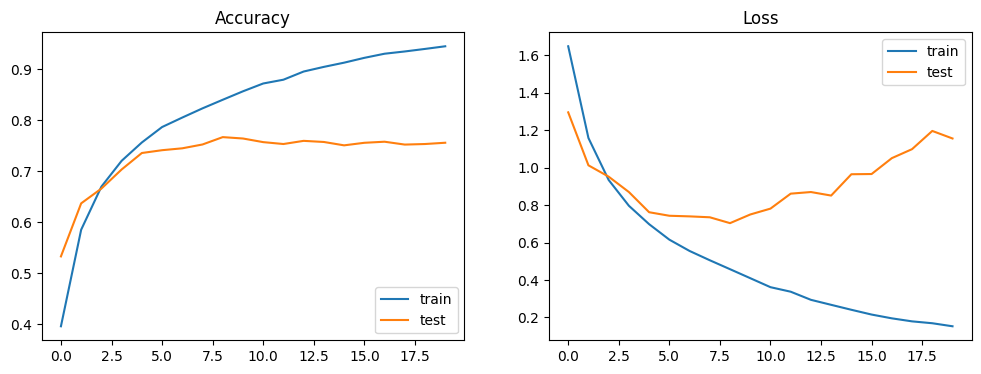

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Elapsed time training= 46.5387 secs
Mean squared error = 0.039
Accuracy = 0.7558
The highest training accuracy was 0.9446 obtained in epoch 20
The final training accuracy was 0.9446
The highest validation accuracy was 0.7667 obtained in epoch 9
The final validation accuracy was 0.7557
The lowest training loss was 0.1529 obtained in epoch 20
The final training loss was 0.1529
The lowest validation loss was 0.7035 obtained in epoch 9
The final validation loss was 1.1555


In [6]:
def cnn(input_shape, conv_units,dense_units):
  model = tf.keras.Sequential()
  model.add(Input(shape=input_shape))
  for c in conv_units:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(dense_units, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn(x_train.shape[1:],[32,48,64],64)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 20,
    batch_size = 100,
    verbose = 2,
    validation_data=(x_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))
print_best_metrics(history.history)

## Mirrored Training Data

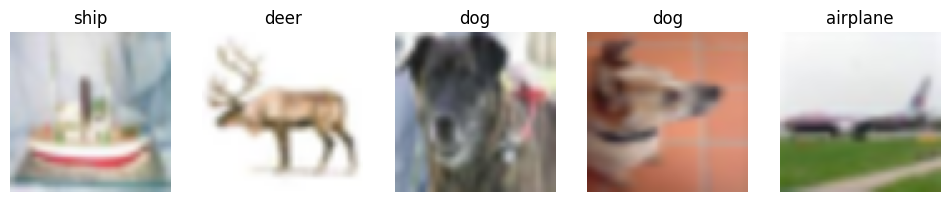

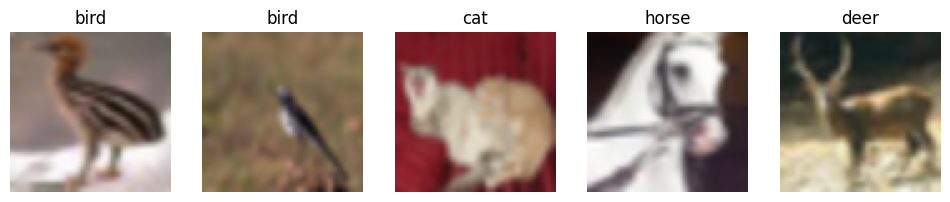

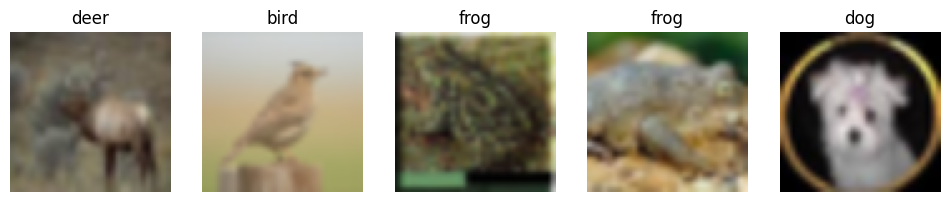

In [7]:
np.random.seed(0)
for k in range(3):
  sel = np.random.randint(0,x_train.shape[0],size = 5)
  k = 2
  fig, ax = plt.subplots(nrows=1,ncols=len(sel), figsize=(12,4))
  for i,s in enumerate(sel):
    ax[i].imshow(cv.resize(x_train[s,:,::-1], (32*k, 32*k)))
    ax[i].set_title(label[np.argmax(y_train[s])])
    ax[i].set_axis_off()

In [8]:
# Add mirrored images to the training data
x_train_mirrored = x_train[:, :, ::-1]
x_train = np.concatenate((x_train, x_train_mirrored), axis=0)
y_train = np.concatenate((y_train, y_train), axis=0)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,690 (686.29 KB)

 Trainable params: 175,690 (686.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1000/1000 - 10s - 10ms/step - accuracy: 0.5073 - loss: 1.3653 - val_accuracy: 0.6322 - val_loss: 1.0286
Epoch 2/20
1000/1000 - 4s - 4ms/step - accuracy: 0.6917 - loss: 0.8822 - val_accuracy: 0.7139 - val_loss: 0.8301
Epoch 3/20
1000/1000 - 4s - 4ms/step - accuracy: 0.7499 - loss: 0.7169 - val_accuracy: 0.7490 - val_loss: 0.7214
Epoch 4/20
1000/1000 - 4s - 4ms/step - accuracy: 0.7888 - loss: 0.6078 - val_accuracy: 0.7781 - val_loss: 0.6426
Epoch 5/20
1000/1000 - 4s - 4ms/step - accuracy: 0.8124 - loss: 0.5387 - val_accuracy: 0.7885 - val_loss: 0.6234
Epoch 6/20
1000/1000 - 4s - 4ms/step - accuracy: 0.8327 - loss: 0.4818 - val_accuracy: 0.7930 - val_loss: 0.6145
Epoch 7/20
1000/1000 - 4s - 4ms/step - accuracy: 0.8483 - loss: 0.4337 - val_accuracy: 0.8008 - val_loss: 0.6147
Epoch 8/20
1000/1000 - 4s - 4ms/step - accuracy: 0.8609 - loss: 0.3960 - val_accuracy: 0.7977 - val_loss: 0.6207
Epoch 9/20
1000/1000 - 4s - 4ms/step - accuracy: 0.8725 - loss: 0.3622 - val_accuracy: 0.8054 

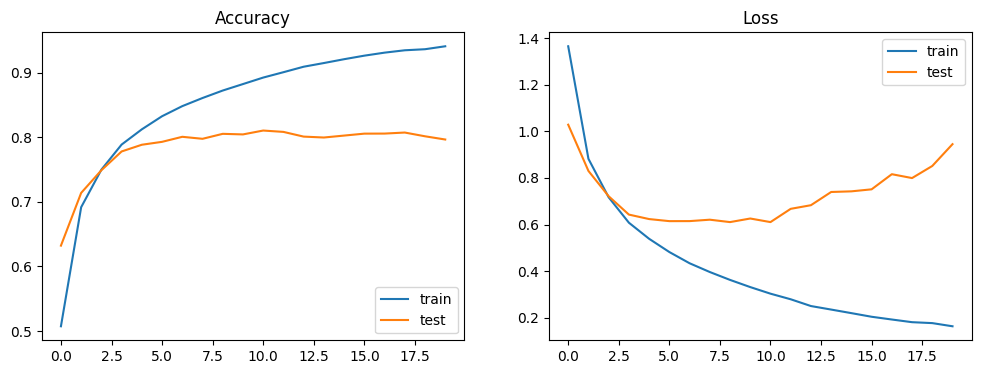

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Elapsed time training= 81.1227 secs
Mean squared error = 0.033
Accuracy = 0.7965
The highest training accuracy was 0.9410 obtained in epoch 20
The final training accuracy was 0.9410
The highest validation accuracy was 0.8105 obtained in epoch 11
The final validation accuracy was 0.7966
The lowest training loss was 0.1631 obtained in epoch 20
The final training loss was 0.1631
The lowest validation loss was 0.6104 obtained in epoch 11
The final validation loss was 0.9451


In [9]:
def cnn(input_shape, conv_units,dense_units):
  model = tf.keras.Sequential()
  model.add(Input(shape=input_shape))
  for c in conv_units:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(dense_units, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn(x_train.shape[1:],[32,48,64],64)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 20,
    batch_size = 100,
    verbose = 2,
    validation_data=(x_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))
print_best_metrics(history.history)

## Mirrored Test-Time Evaluation

Since the training is identical, we don't need to retrain the model. We will use the model from the previous experiment.

In [10]:
x_test_mirrored = x_test[:, :, ::-1]
x_test = np.concatenate((x_test, x_test_mirrored), axis=0)
y_test = np.concatenate((y_test, y_test), axis=0)

In [11]:
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))
print_best_metrics(history.history)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Elapsed time training= 81.1227 secs
Mean squared error = 0.032
Accuracy = 0.7964
The highest training accuracy was 0.9410 obtained in epoch 20
The final training accuracy was 0.9410
The highest validation accuracy was 0.8105 obtained in epoch 11
The final validation accuracy was 0.7966
The lowest training loss was 0.1631 obtained in epoch 20
The final training loss was 0.1631
The lowest validation loss was 0.6104 obtained in epoch 11
The final validation loss was 0.9451


## Baseline, Size, Kernel, and Depth Experiments

In [12]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.regularizers import *
from tensorflow.keras.layers import *
from tensorflow.keras.losses import *
from tensorflow.keras.activations import *
from keras.utils import plot_model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error

def plot_results(history):
  fig, ax = plt.subplots(ncols=2, figsize=(12,4))
  ax[0].plot(history.history['accuracy'],label = 'train')
  ax[0].plot(history.history['val_accuracy'],label = 'test')
  ax[0].set_title('Accuracy')
  ax[0].legend(loc='lower right')
  ax[1].plot(history.history['loss'],label = 'train')
  ax[1].plot(history.history['val_loss'],label = 'test')
  ax[1].set_title('Loss')
  ax[1].legend(loc='upper right')
  plt.show()

def print_best_metrics(h):
  labels = ['training accuracy', 'validation accuracy', 'training loss', 'validation loss']
  keys = ['accuracy', 'val_accuracy', 'loss', 'val_loss']
  prefix = ['highest','lowest']
  for i in range(4):
    metric = np.array(h[keys[i]])
    am = np.argmax((1.5-i)*metric)
    print(f'The {prefix[i//2]} {labels[i]} was {metric[am]:.4f} obtained in epoch {am+1}')
    print(f'The final {labels[i]} was {metric[-1]:.4f}')

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = np.float32(x_train/255.0)
x_test = np.float32(x_test/255.0)

### Baseline CNN

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,250 (1.08 MB)

 Trainable params: 282,250 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

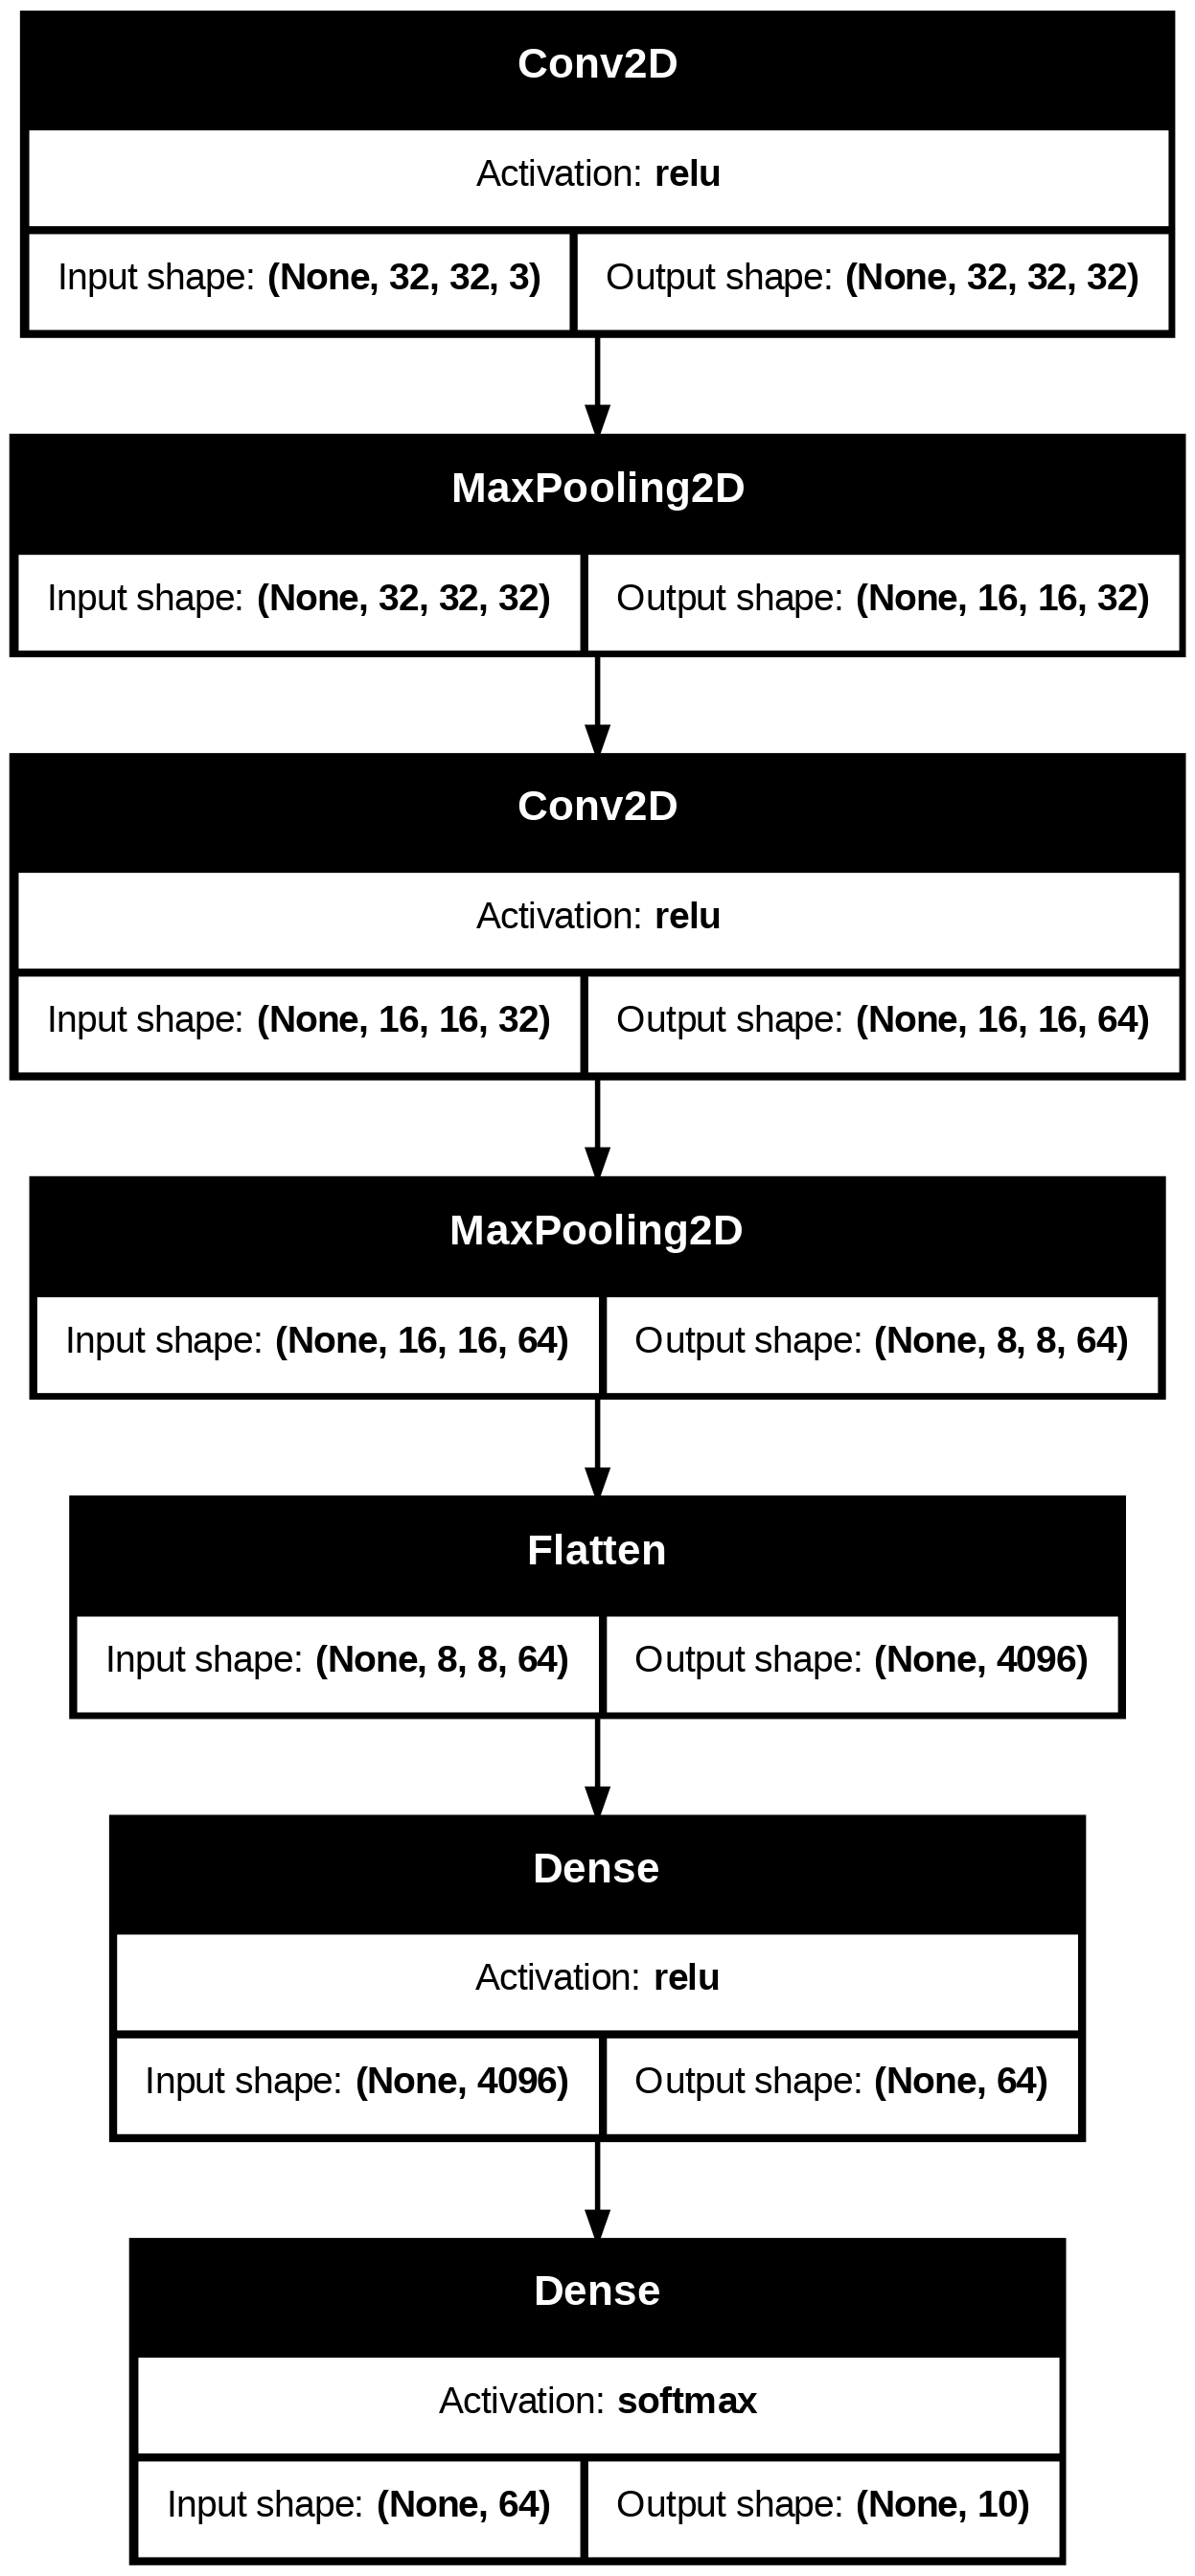

In [13]:
def cnn_model(input_shape=(32,32,3), conv_units = (32,64)):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(64, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn_model()
model.summary()
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
250/250 - 6s - 24ms/step - accuracy: 0.4221 - loss: 1.6050 - val_accuracy: 0.5258 - val_loss: 1.3342
Epoch 2/20
250/250 - 1s - 4ms/step - accuracy: 0.5566 - loss: 1.2504 - val_accuracy: 0.5820 - val_loss: 1.1797
Epoch 3/20
250/250 - 1s - 4ms/step - accuracy: 0.6118 - loss: 1.1050 - val_accuracy: 0.6140 - val_loss: 1.0803
Epoch 4/20
250/250 - 1s - 4ms/step - accuracy: 0.6499 - loss: 1.0043 - val_accuracy: 0.6326 - val_loss: 1.0406
Epoch 5/20
250/250 - 1s - 4ms/step - accuracy: 0.6713 - loss: 0.9442 - val_accuracy: 0.6425 - val_loss: 1.0201
Epoch 6/20
250/250 - 1s - 4ms/step - accuracy: 0.6893 - loss: 0.8920 - val_accuracy: 0.6703 - val_loss: 0.9400
Epoch 7/20
250/250 - 1s - 4ms/step - accuracy: 0.7076 - loss: 0.8429 - val_accuracy: 0.6887 - val_loss: 0.9122
Epoch 8/20
250/250 - 1s - 4ms/step - accuracy: 0.7218 - loss: 0.8036 - val_accuracy: 0.6889 - val_loss: 0.9017
Epoch 9/20
250/250 - 1s - 4ms/step - accuracy: 0.7333 - loss: 0.7656 - val_accuracy: 0.6826 - val_loss: 0.9297


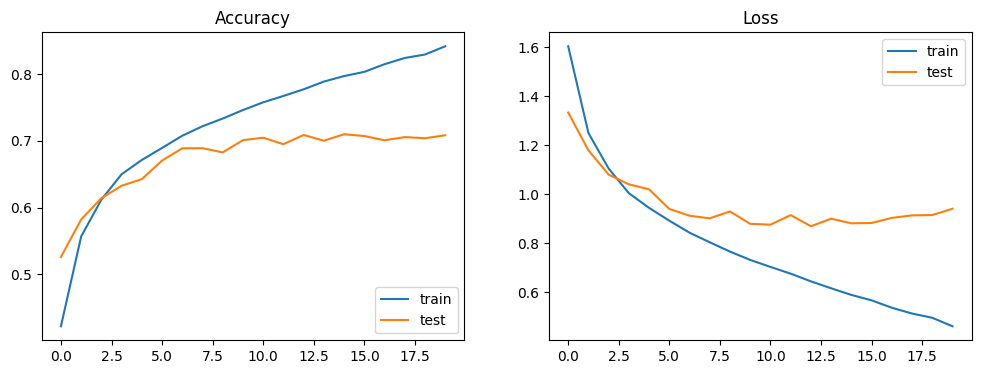

In [14]:
opt = tf.keras.optimizers.Adam()
model = cnn_model()

model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  20,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print_best_metrics(history.history)
plot_results(history)

## Reduced Network Size

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │       131,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 150,826 (589.16 KB)

 Trainable params: 150,826 (589.16 KB)

 Non-trainable params: 0 (0.00 B)

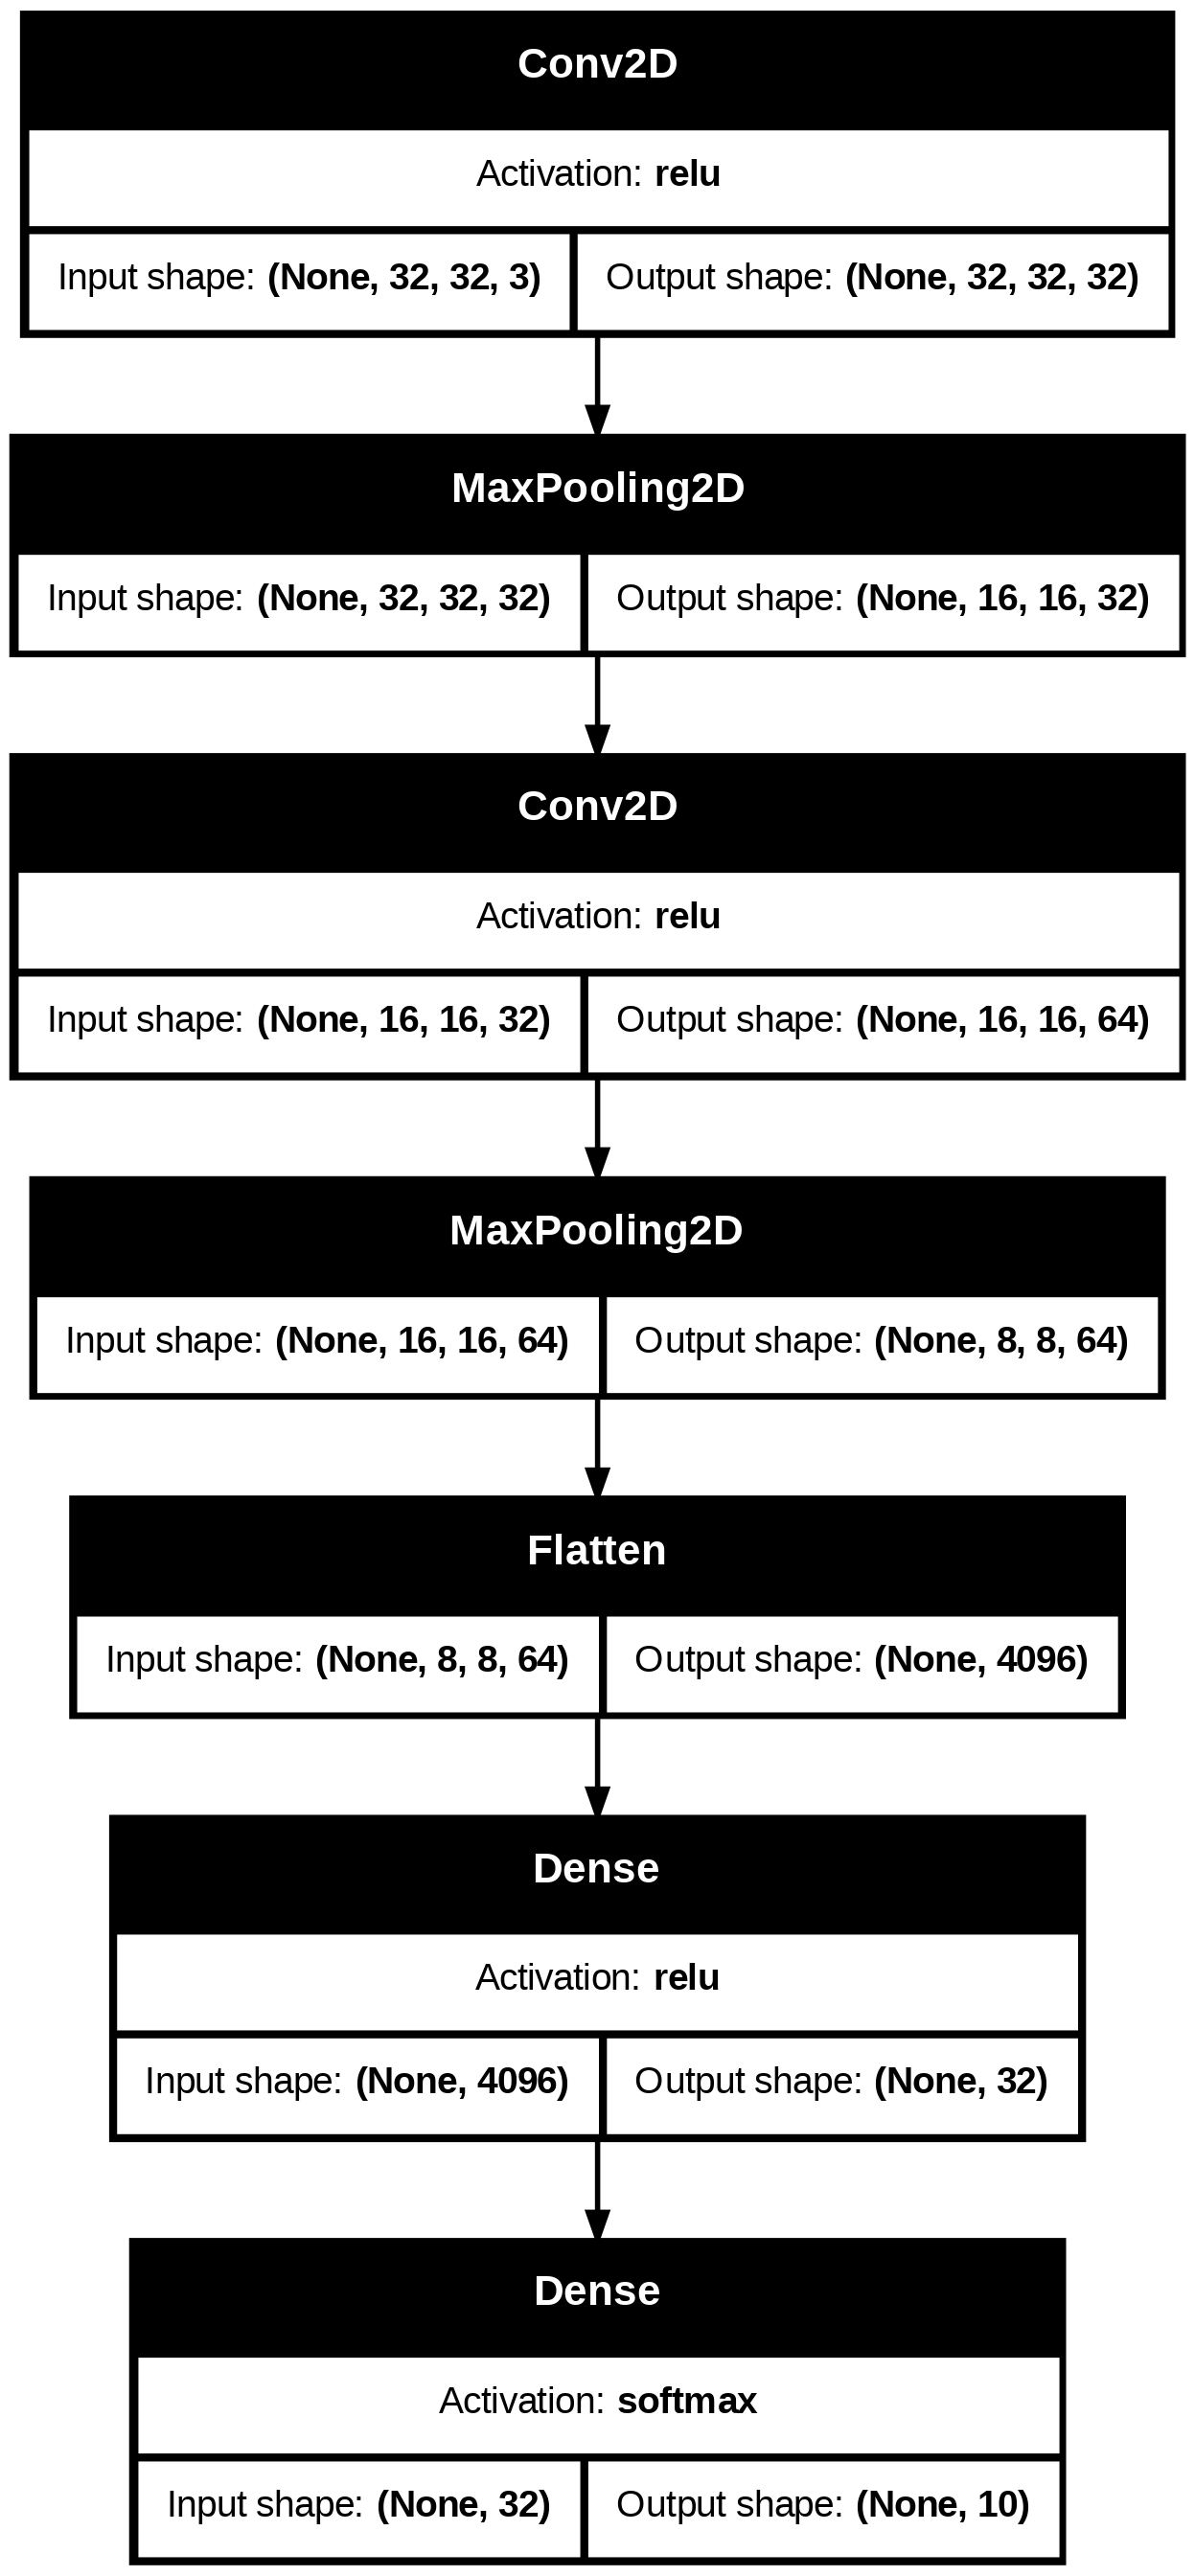

In [15]:
def cnn_model(input_shape=(32,32,3), conv_units = (32,64)):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(32, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn_model()
model.summary()
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
250/250 - 6s - 25ms/step - accuracy: 0.3908 - loss: 1.7056 - val_accuracy: 0.4964 - val_loss: 1.4240
Epoch 2/50
250/250 - 1s - 4ms/step - accuracy: 0.5182 - loss: 1.3591 - val_accuracy: 0.5301 - val_loss: 1.3185
Epoch 3/50
250/250 - 1s - 4ms/step - accuracy: 0.5675 - loss: 1.2304 - val_accuracy: 0.5801 - val_loss: 1.2088
Epoch 4/50
250/250 - 1s - 4ms/step - accuracy: 0.5993 - loss: 1.1495 - val_accuracy: 0.6108 - val_loss: 1.1296
Epoch 5/50
250/250 - 1s - 4ms/step - accuracy: 0.6216 - loss: 1.0871 - val_accuracy: 0.6311 - val_loss: 1.0628
Epoch 6/50
250/250 - 1s - 4ms/step - accuracy: 0.6436 - loss: 1.0259 - val_accuracy: 0.6368 - val_loss: 1.0479
Epoch 7/50
250/250 - 1s - 4ms/step - accuracy: 0.6619 - loss: 0.9792 - val_accuracy: 0.6589 - val_loss: 0.9931
Epoch 8/50
250/250 - 1s - 4ms/step - accuracy: 0.6729 - loss: 0.9474 - val_accuracy: 0.6675 - val_loss: 0.9719
Epoch 9/50
250/250 - 1s - 4ms/step - accuracy: 0.6839 - loss: 0.9105 - val_accuracy: 0.6712 - val_loss: 0.9530


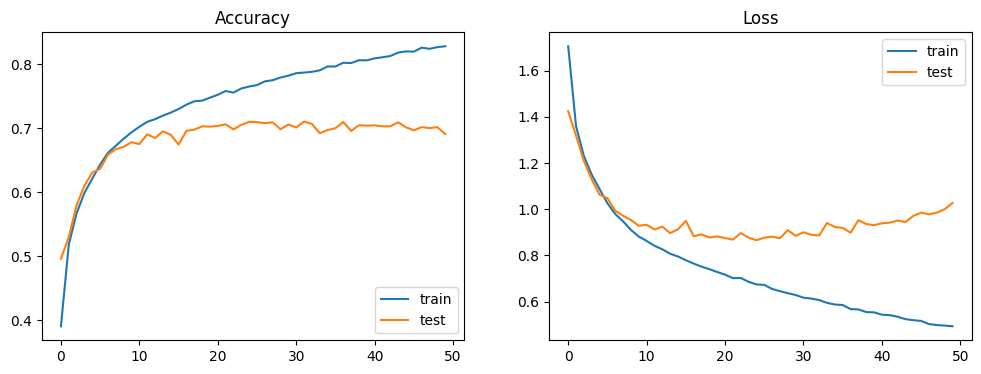

In [16]:
opt = tf.keras.optimizers.Adam()
model = cnn_model(conv_units = (32,32))

model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  50,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print_best_metrics(history.history)
plot_results(history)

## Larger Convolution Kernels

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 16, 16, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 297,258 (1.13 MB)

 Trainable params: 297,258 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

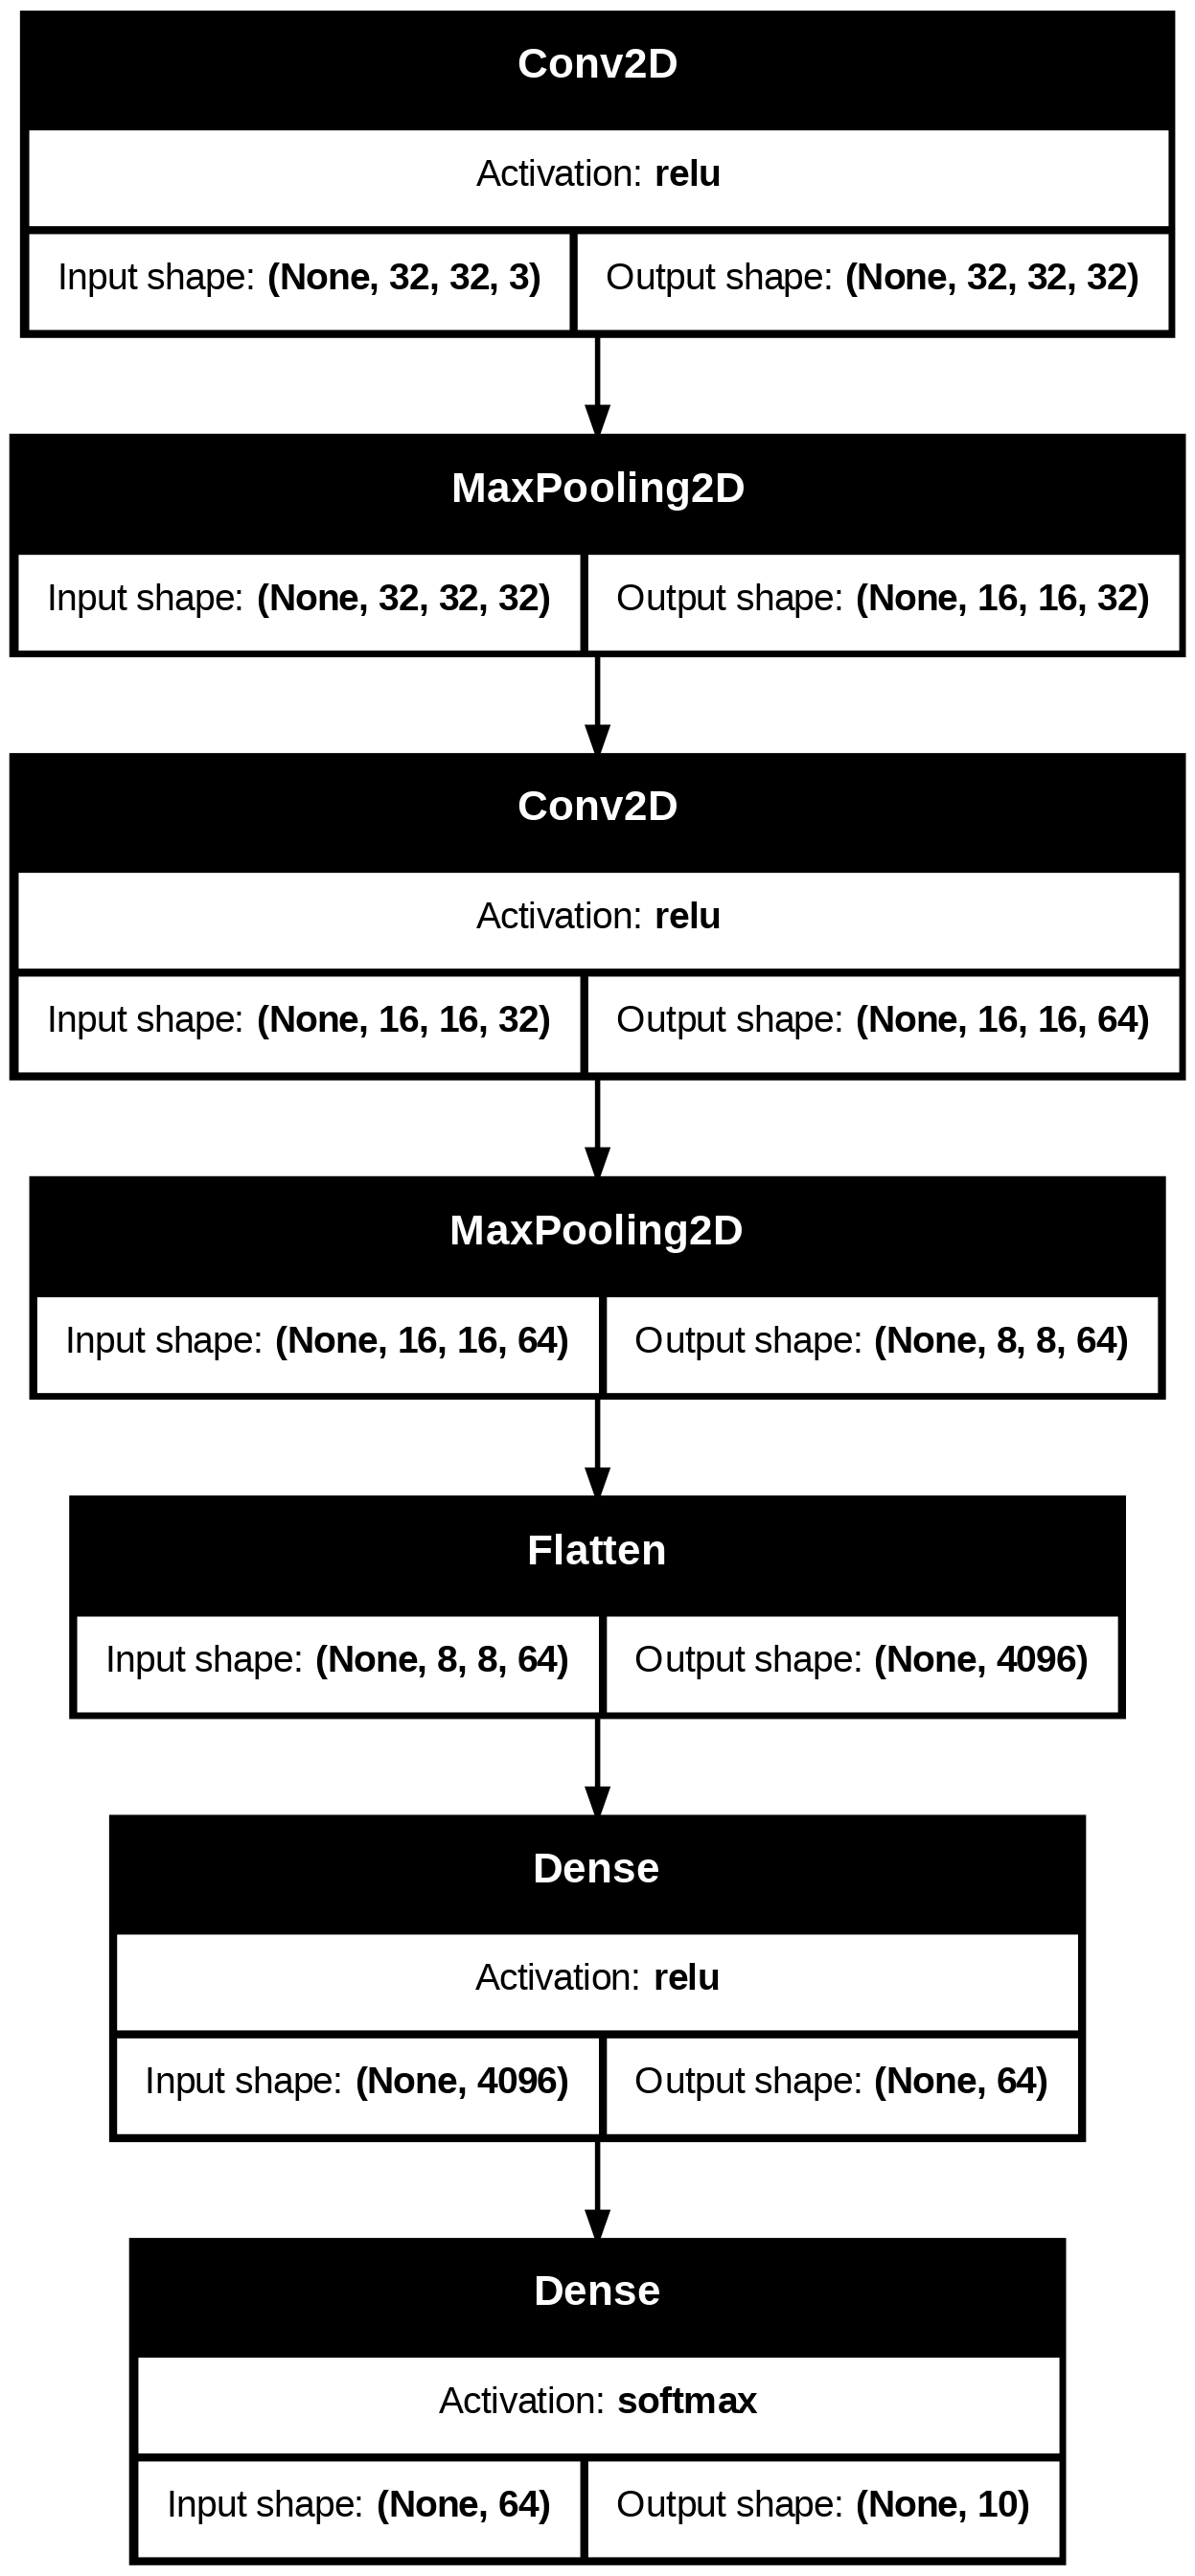

In [17]:
def cnn_model(input_shape=(32,32,3), conv_units = (32,64)):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(4, 4), input_shape=input_shape, padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(4, 4),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(64, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn_model()
model.summary()
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
250/250 - 5s - 21ms/step - accuracy: 0.3941 - loss: 1.6670 - val_accuracy: 0.5060 - val_loss: 1.3853
Epoch 2/20
250/250 - 1s - 4ms/step - accuracy: 0.5431 - loss: 1.2890 - val_accuracy: 0.5754 - val_loss: 1.2009
Epoch 3/20
250/250 - 1s - 4ms/step - accuracy: 0.6092 - loss: 1.1188 - val_accuracy: 0.6115 - val_loss: 1.0861
Epoch 4/20
250/250 - 1s - 4ms/step - accuracy: 0.6483 - loss: 1.0100 - val_accuracy: 0.6480 - val_loss: 0.9997
Epoch 5/20
250/250 - 1s - 4ms/step - accuracy: 0.6753 - loss: 0.9324 - val_accuracy: 0.6694 - val_loss: 0.9514
Epoch 6/20
250/250 - 1s - 4ms/step - accuracy: 0.6944 - loss: 0.8779 - val_accuracy: 0.6779 - val_loss: 0.9408
Epoch 7/20
250/250 - 1s - 4ms/step - accuracy: 0.7110 - loss: 0.8316 - val_accuracy: 0.6769 - val_loss: 0.9382
Epoch 8/20
250/250 - 1s - 4ms/step - accuracy: 0.7294 - loss: 0.7853 - val_accuracy: 0.6848 - val_loss: 0.9144
Epoch 9/20
250/250 - 1s - 4ms/step - accuracy: 0.7400 - loss: 0.7489 - val_accuracy: 0.6982 - val_loss: 0.8777


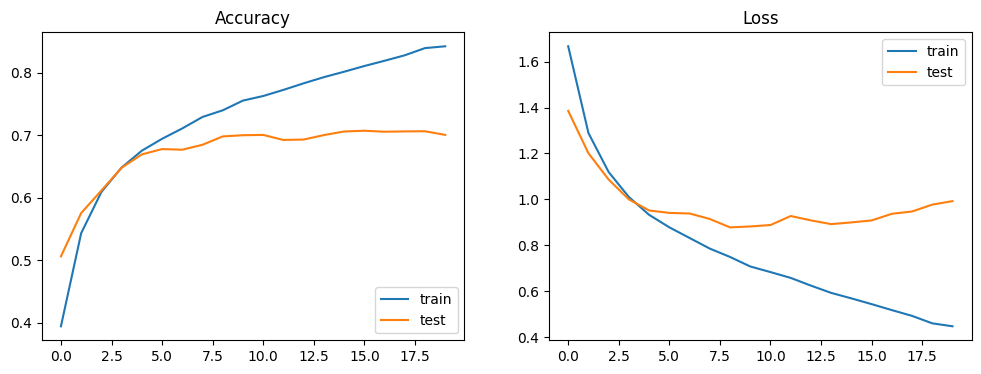

In [18]:
opt = tf.keras.optimizers.Adam()
model = cnn_model()

model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  20,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print_best_metrics(history.history)
plot_results(history)

## Back-to-Back Convolutions

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,426 (1.25 MB)

 Trainable params: 328,426 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

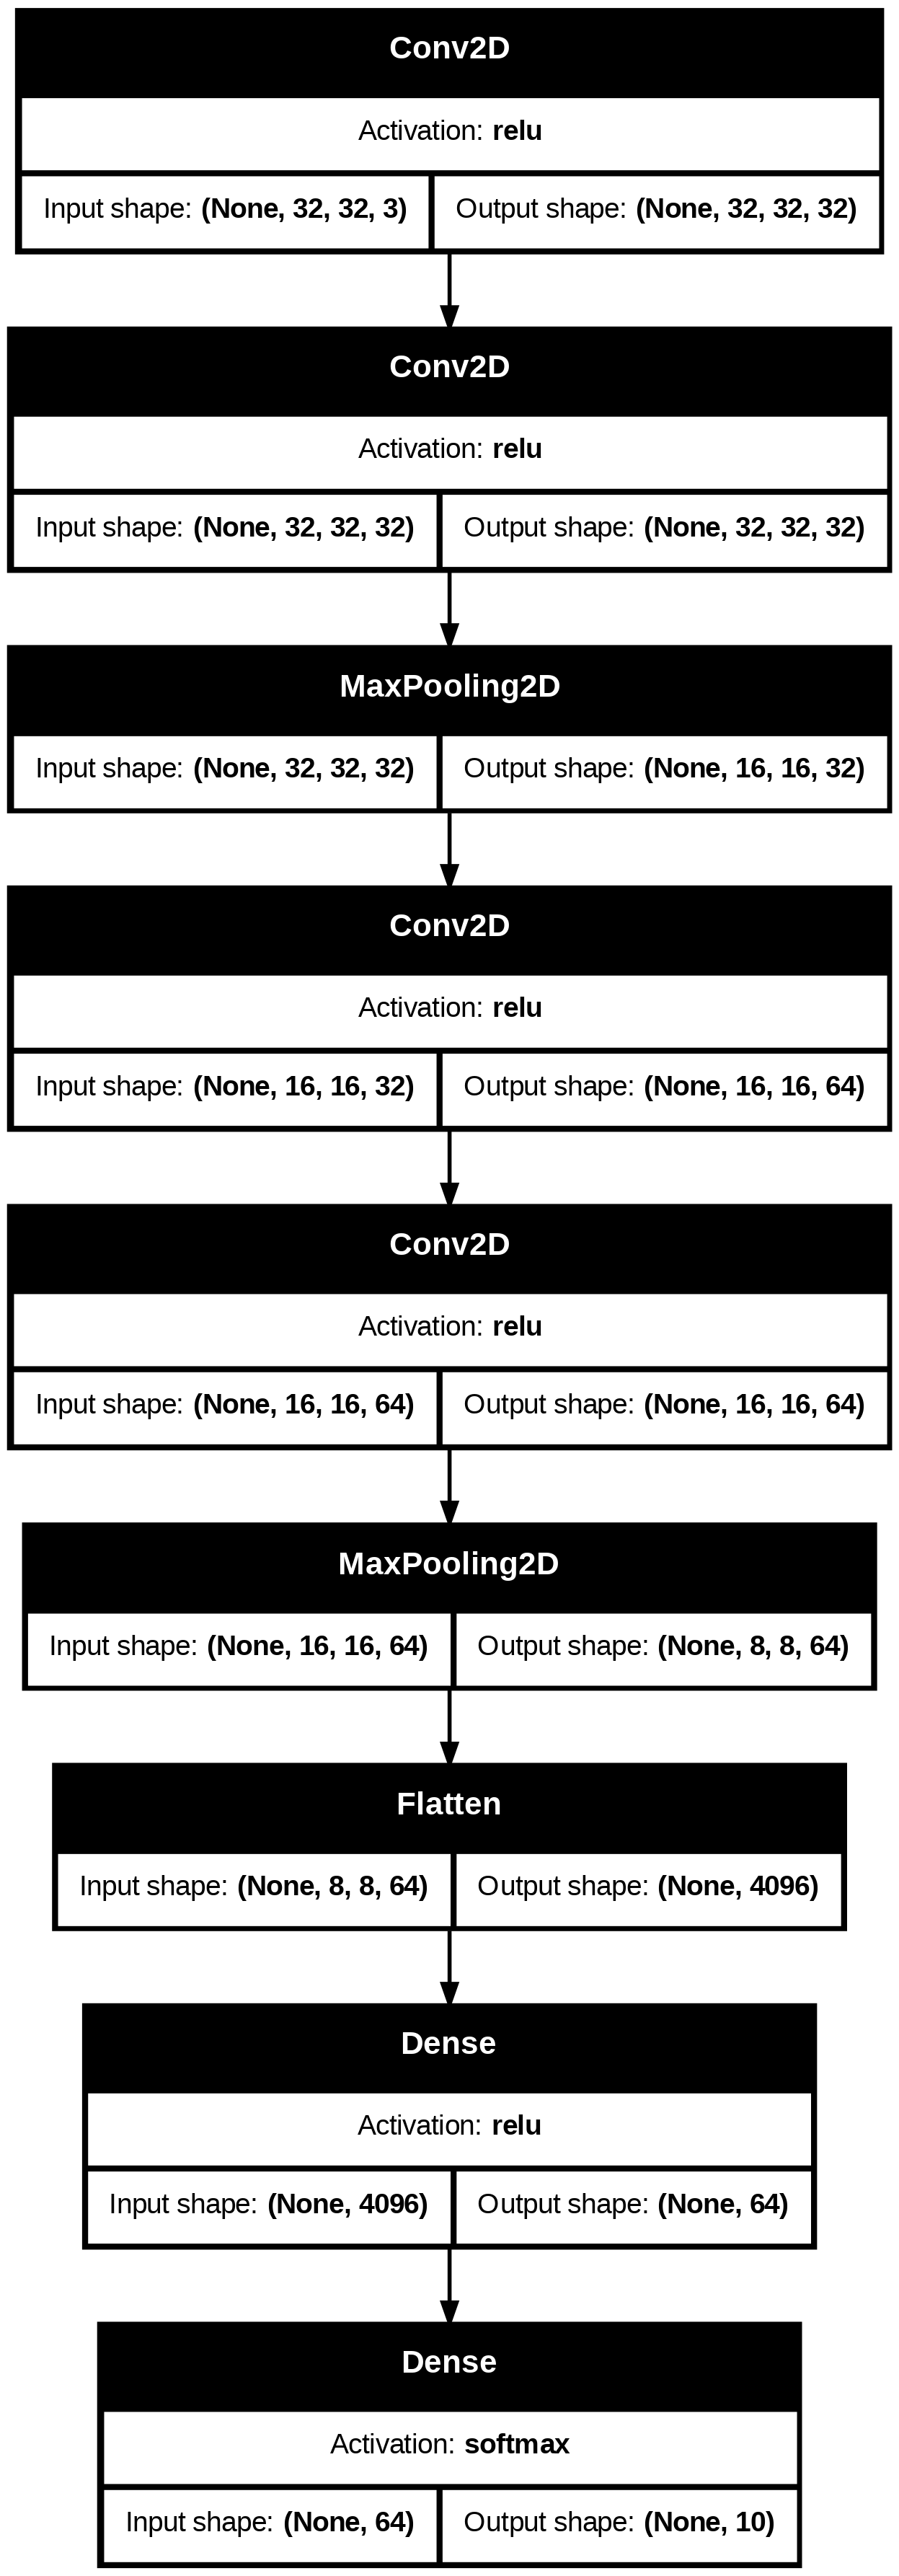

In [19]:
def cnn_model(input_shape=(32,32,3), conv_units = (32,64)):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(64, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn_model()
model.summary()
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
250/250 - 6s - 25ms/step - accuracy: 0.4370 - loss: 1.5507 - val_accuracy: 0.5664 - val_loss: 1.2152
Epoch 2/20
250/250 - 1s - 5ms/step - accuracy: 0.6117 - loss: 1.1084 - val_accuracy: 0.6519 - val_loss: 1.0013
Epoch 3/20
250/250 - 1s - 5ms/step - accuracy: 0.6735 - loss: 0.9338 - val_accuracy: 0.6696 - val_loss: 0.9394
Epoch 4/20
250/250 - 1s - 5ms/step - accuracy: 0.7103 - loss: 0.8371 - val_accuracy: 0.6898 - val_loss: 0.9022
Epoch 5/20
250/250 - 1s - 5ms/step - accuracy: 0.7384 - loss: 0.7498 - val_accuracy: 0.7137 - val_loss: 0.8383
Epoch 6/20
250/250 - 1s - 5ms/step - accuracy: 0.7638 - loss: 0.6832 - val_accuracy: 0.7173 - val_loss: 0.8173
Epoch 7/20
250/250 - 1s - 5ms/step - accuracy: 0.7869 - loss: 0.6197 - val_accuracy: 0.7307 - val_loss: 0.7746
Epoch 8/20
250/250 - 1s - 5ms/step - accuracy: 0.8023 - loss: 0.5649 - val_accuracy: 0.7440 - val_loss: 0.7644
Epoch 9/20
250/250 - 1s - 5ms/step - accuracy: 0.8239 - loss: 0.5109 - val_accuracy: 0.7406 - val_loss: 0.7865


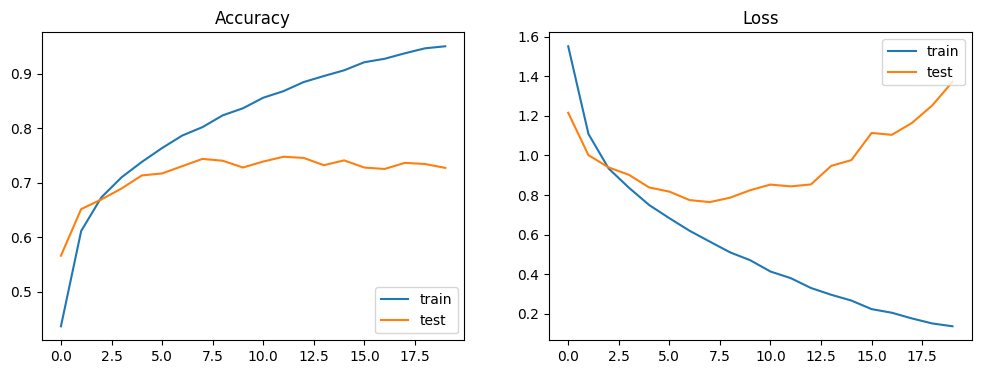

In [20]:
opt = tf.keras.optimizers.Adam()
model = cnn_model()

model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  20,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print_best_metrics(history.history)
plot_results(history)

## Architecture Depth Experiments

## Increasing Network Depth

### Additional Dense Layer After Flattening

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_35 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 500)            │     2,048,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,100,606 (8.01 MB)

 Trainable params: 2,100,606 (8.01 MB)

 Non-trainable params: 0 (0.00 B)

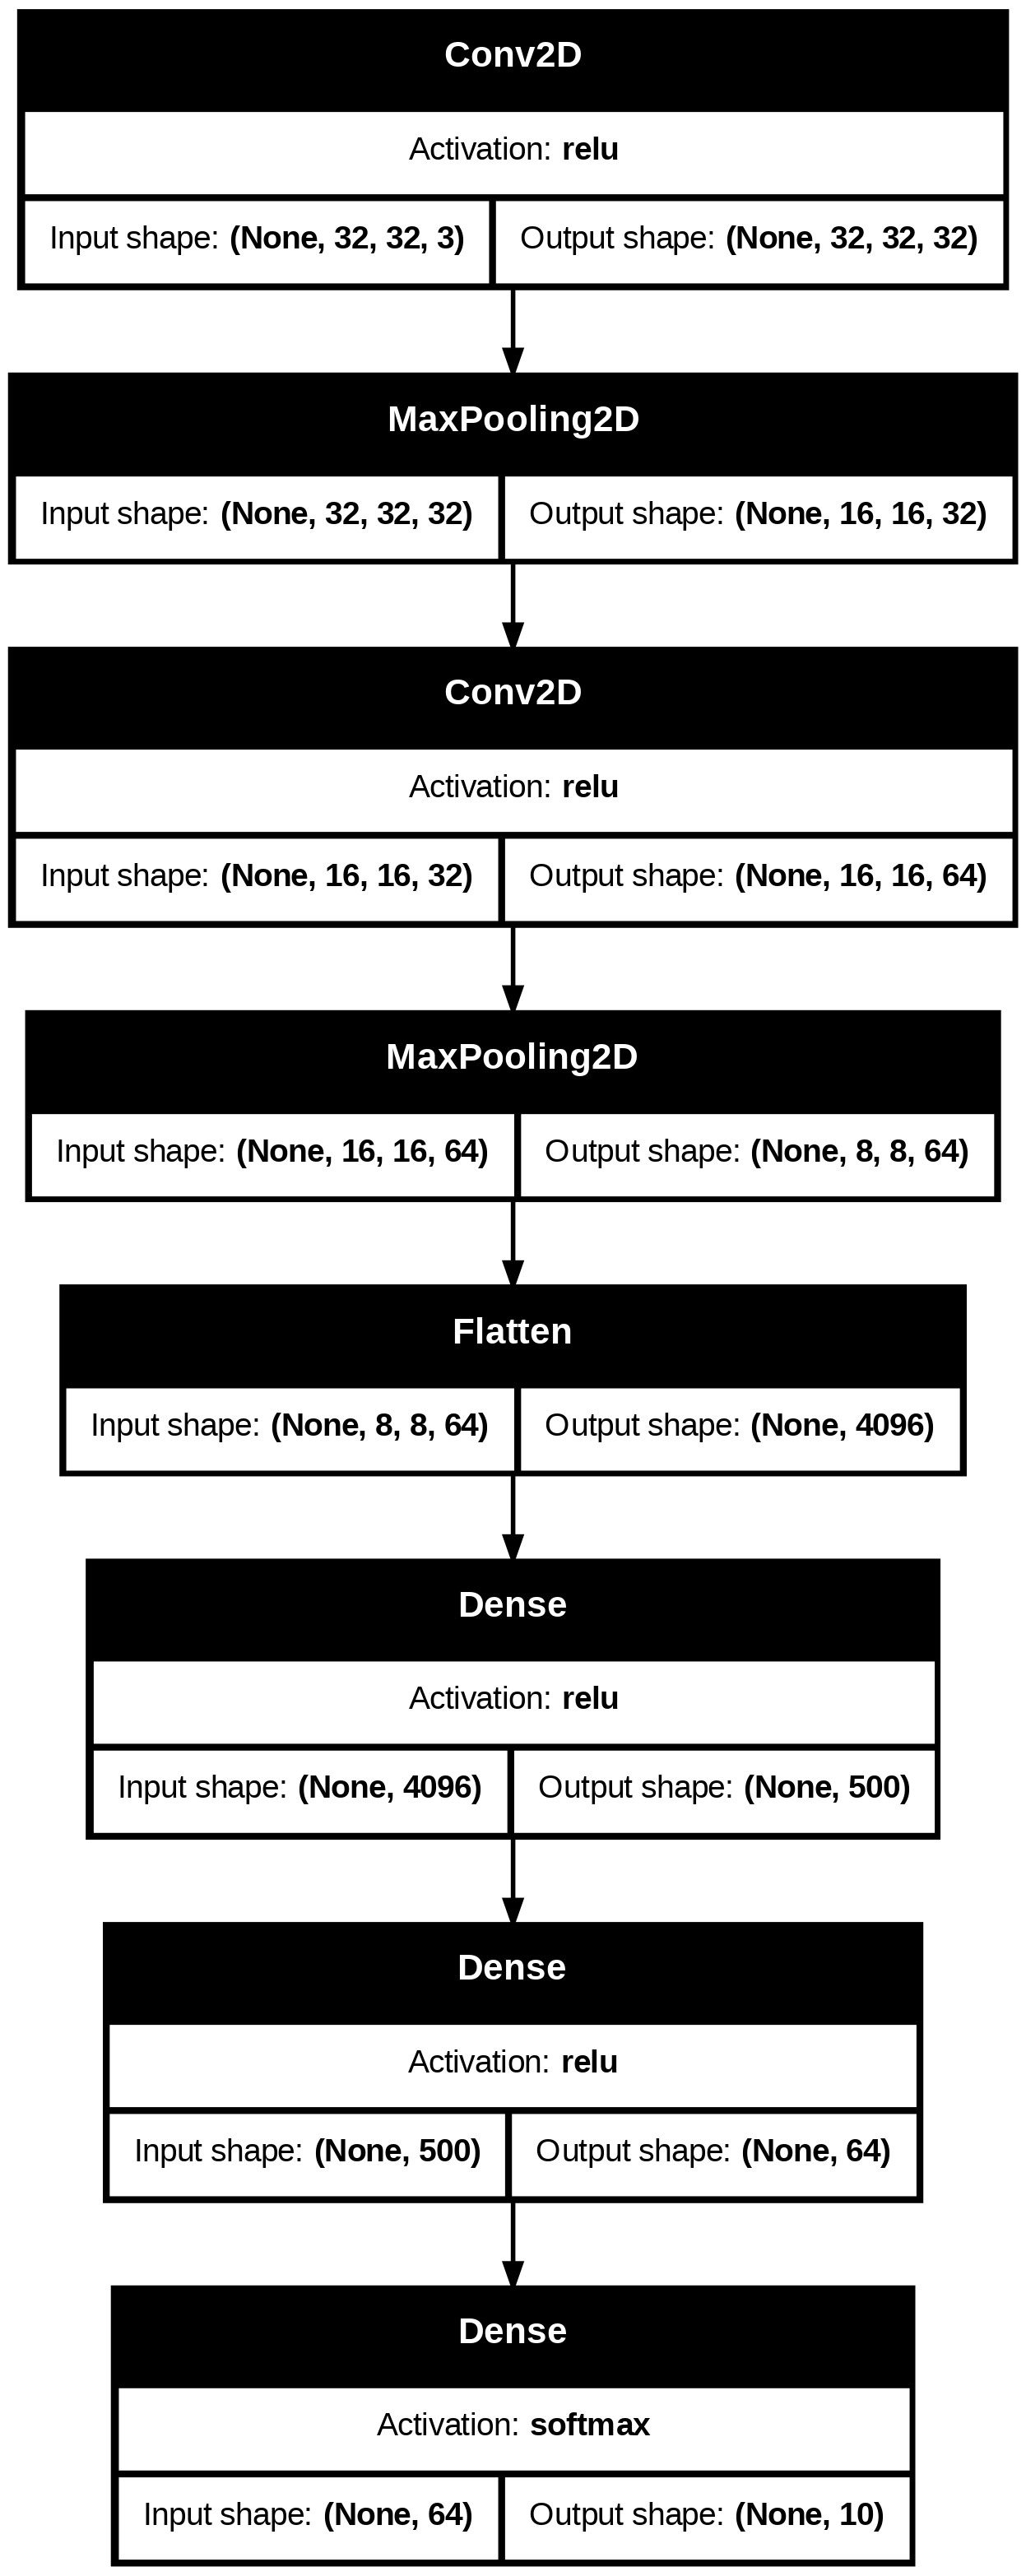

In [21]:
def cnn_model(input_shape=(32,32,3), conv_units = (32,64)):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(500, activation='relu'))
  model.add(Dense(64, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn_model()
model.summary()
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
250/250 - 11s - 42ms/step - accuracy: 0.4470 - loss: 1.5421 - val_accuracy: 0.5476 - val_loss: 1.2547
Epoch 2/20
250/250 - 1s - 4ms/step - accuracy: 0.5960 - loss: 1.1481 - val_accuracy: 0.6273 - val_loss: 1.0629
Epoch 3/20
250/250 - 1s - 4ms/step - accuracy: 0.6546 - loss: 0.9861 - val_accuracy: 0.6519 - val_loss: 0.9900
Epoch 4/20
250/250 - 1s - 4ms/step - accuracy: 0.6901 - loss: 0.8829 - val_accuracy: 0.6776 - val_loss: 0.9283
Epoch 5/20
250/250 - 1s - 4ms/step - accuracy: 0.7255 - loss: 0.7894 - val_accuracy: 0.7036 - val_loss: 0.8697
Epoch 6/20
250/250 - 1s - 4ms/step - accuracy: 0.7489 - loss: 0.7173 - val_accuracy: 0.6988 - val_loss: 0.8642
Epoch 7/20
250/250 - 1s - 4ms/step - accuracy: 0.7740 - loss: 0.6476 - val_accuracy: 0.7071 - val_loss: 0.8695
Epoch 8/20
250/250 - 1s - 4ms/step - accuracy: 0.8018 - loss: 0.5671 - val_accuracy: 0.7102 - val_loss: 0.8724
Epoch 9/20
250/250 - 1s - 4ms/step - accuracy: 0.8251 - loss: 0.5014 - val_accuracy: 0.7132 - val_loss: 0.8663

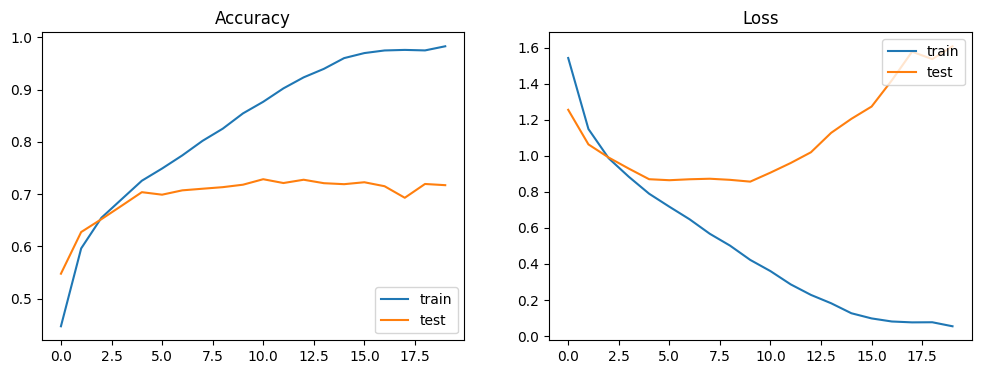

In [22]:
opt = tf.keras.optimizers.Adam()
model = cnn_model()

model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  20,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print_best_metrics(history.history)
plot_results(history)

### Additional Convolution-Pooling Block

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_39 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

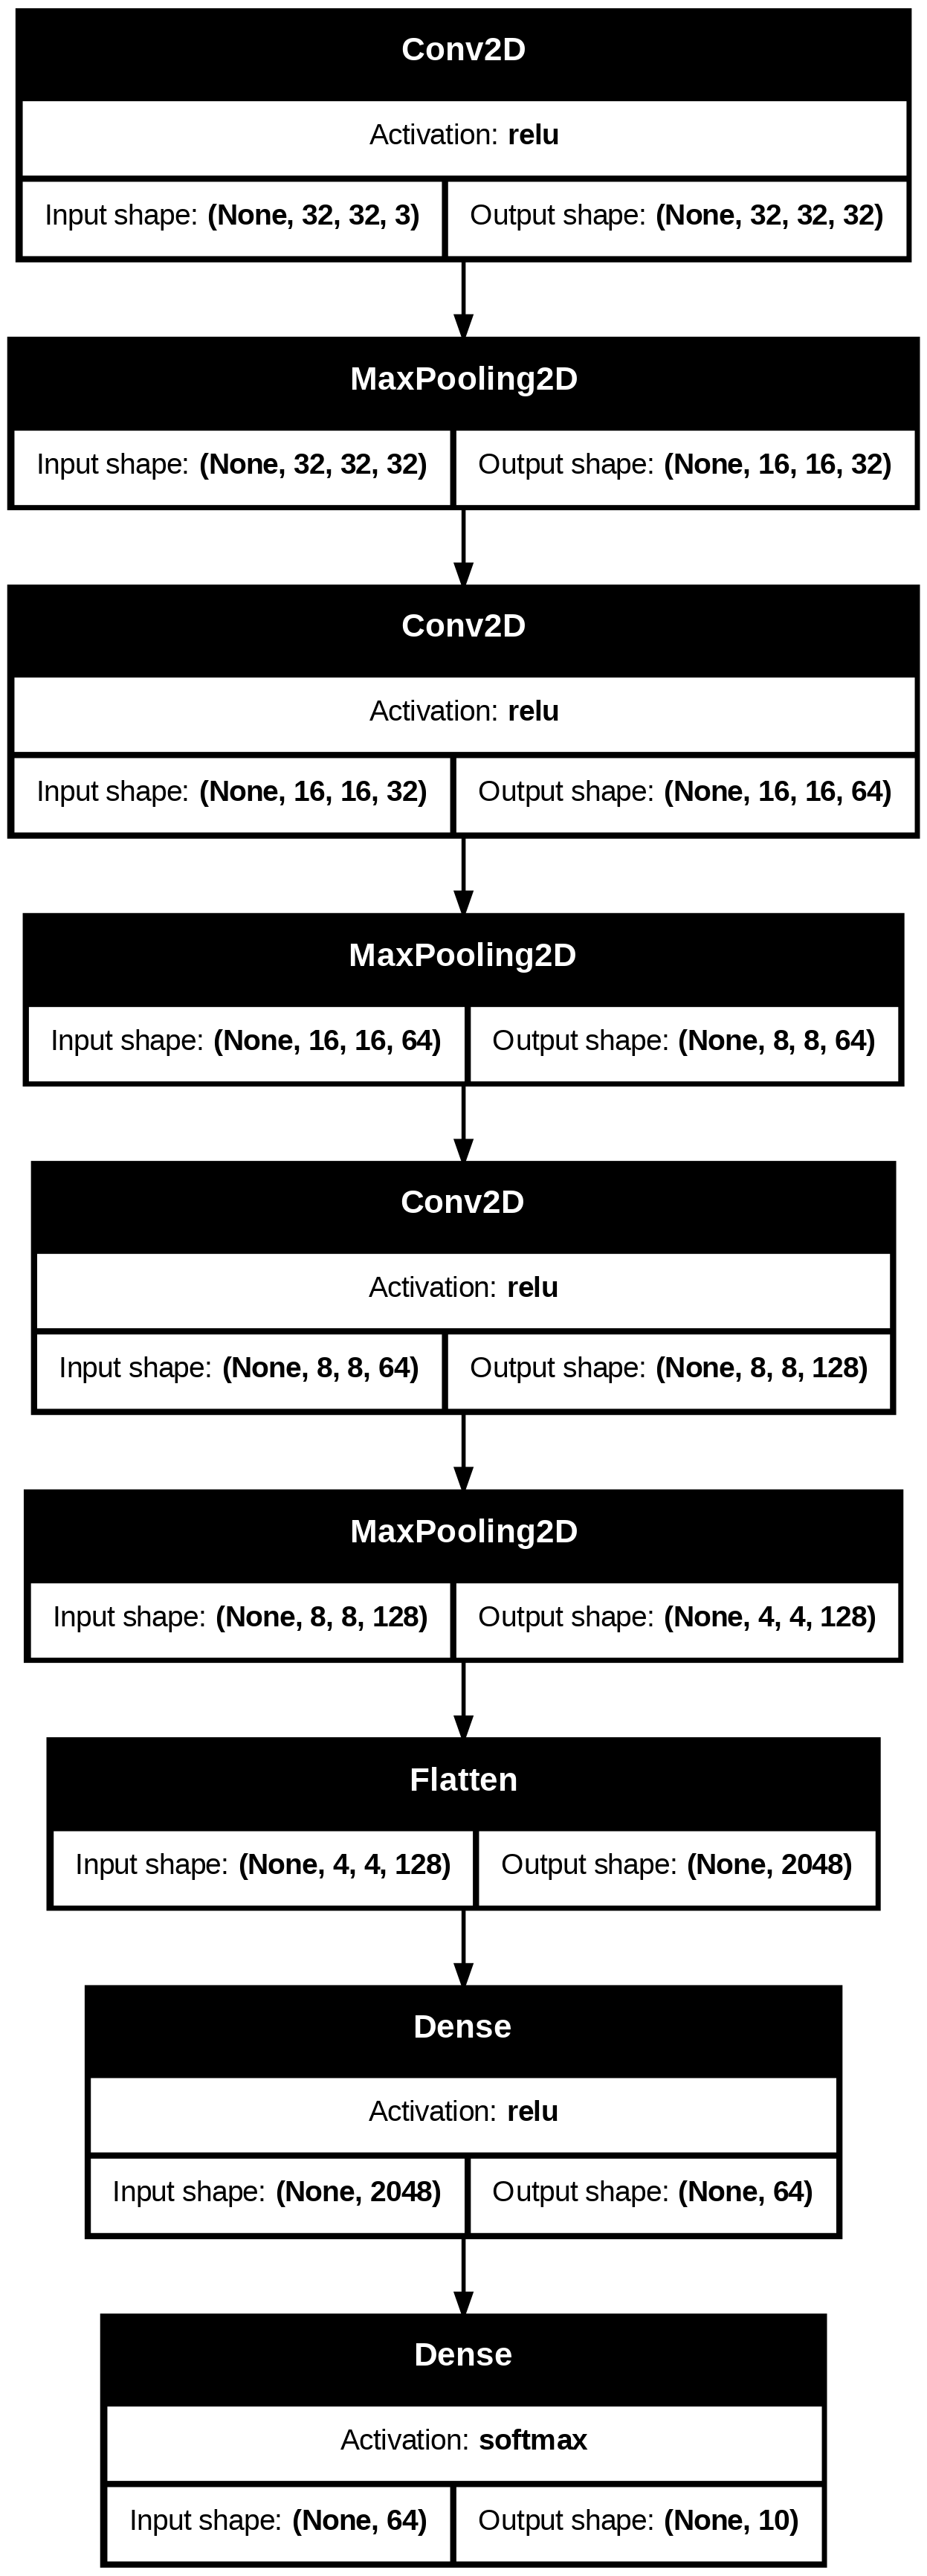

In [23]:
def cnn_model(input_shape=(32,32,3), conv_units = (32, 64)):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(64, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn_model(conv_units = (32, 64, 128))
model.summary()
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
250/250 - 5s - 18ms/step - accuracy: 0.4155 - loss: 1.6282 - val_accuracy: 0.5121 - val_loss: 1.3585
Epoch 2/30
250/250 - 1s - 4ms/step - accuracy: 0.5534 - loss: 1.2704 - val_accuracy: 0.5909 - val_loss: 1.1751
Epoch 3/30
250/250 - 1s - 4ms/step - accuracy: 0.6041 - loss: 1.1355 - val_accuracy: 0.6086 - val_loss: 1.1215
Epoch 4/30
250/250 - 1s - 4ms/step - accuracy: 0.6377 - loss: 1.0439 - val_accuracy: 0.6299 - val_loss: 1.0600
Epoch 5/30
250/250 - 1s - 4ms/step - accuracy: 0.6618 - loss: 0.9770 - val_accuracy: 0.6596 - val_loss: 0.9971
Epoch 6/30
250/250 - 1s - 4ms/step - accuracy: 0.6799 - loss: 0.9250 - val_accuracy: 0.6430 - val_loss: 1.0337
Epoch 7/30
250/250 - 1s - 4ms/step - accuracy: 0.6944 - loss: 0.8804 - val_accuracy: 0.6857 - val_loss: 0.9268
Epoch 8/30
250/250 - 1s - 4ms/step - accuracy: 0.7100 - loss: 0.8390 - val_accuracy: 0.6785 - val_loss: 0.9357
Epoch 9/30
250/250 - 1s - 4ms/step - accuracy: 0.7203 - loss: 0.8079 - val_accuracy: 0.6774 - val_loss: 0.9418


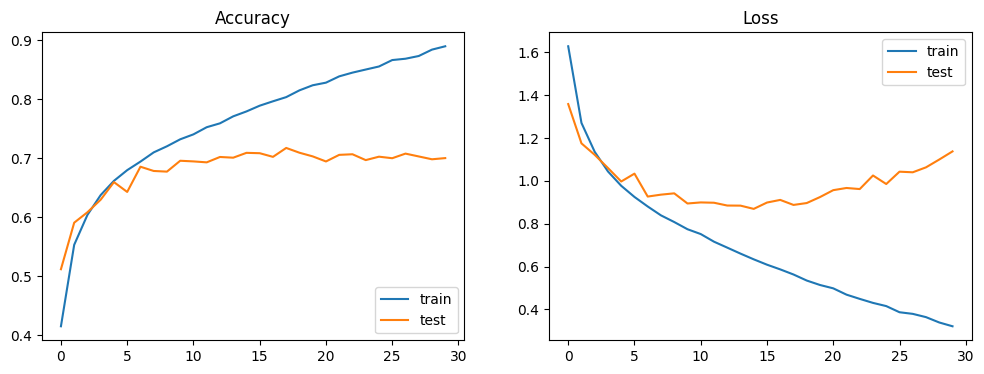

In [24]:
opt = tf.keras.optimizers.Adam()
model = cnn_model()

model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  30,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print_best_metrics(history.history)
plot_results(history)

## Combined Increased Depth and Back-to-Back Convolutions

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_44 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 500)            │     2,048,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,146,782 (8.19 MB)

 Trainable params: 2,146,782 (8.19 MB)

 Non-trainable params: 0 (0.00 B)

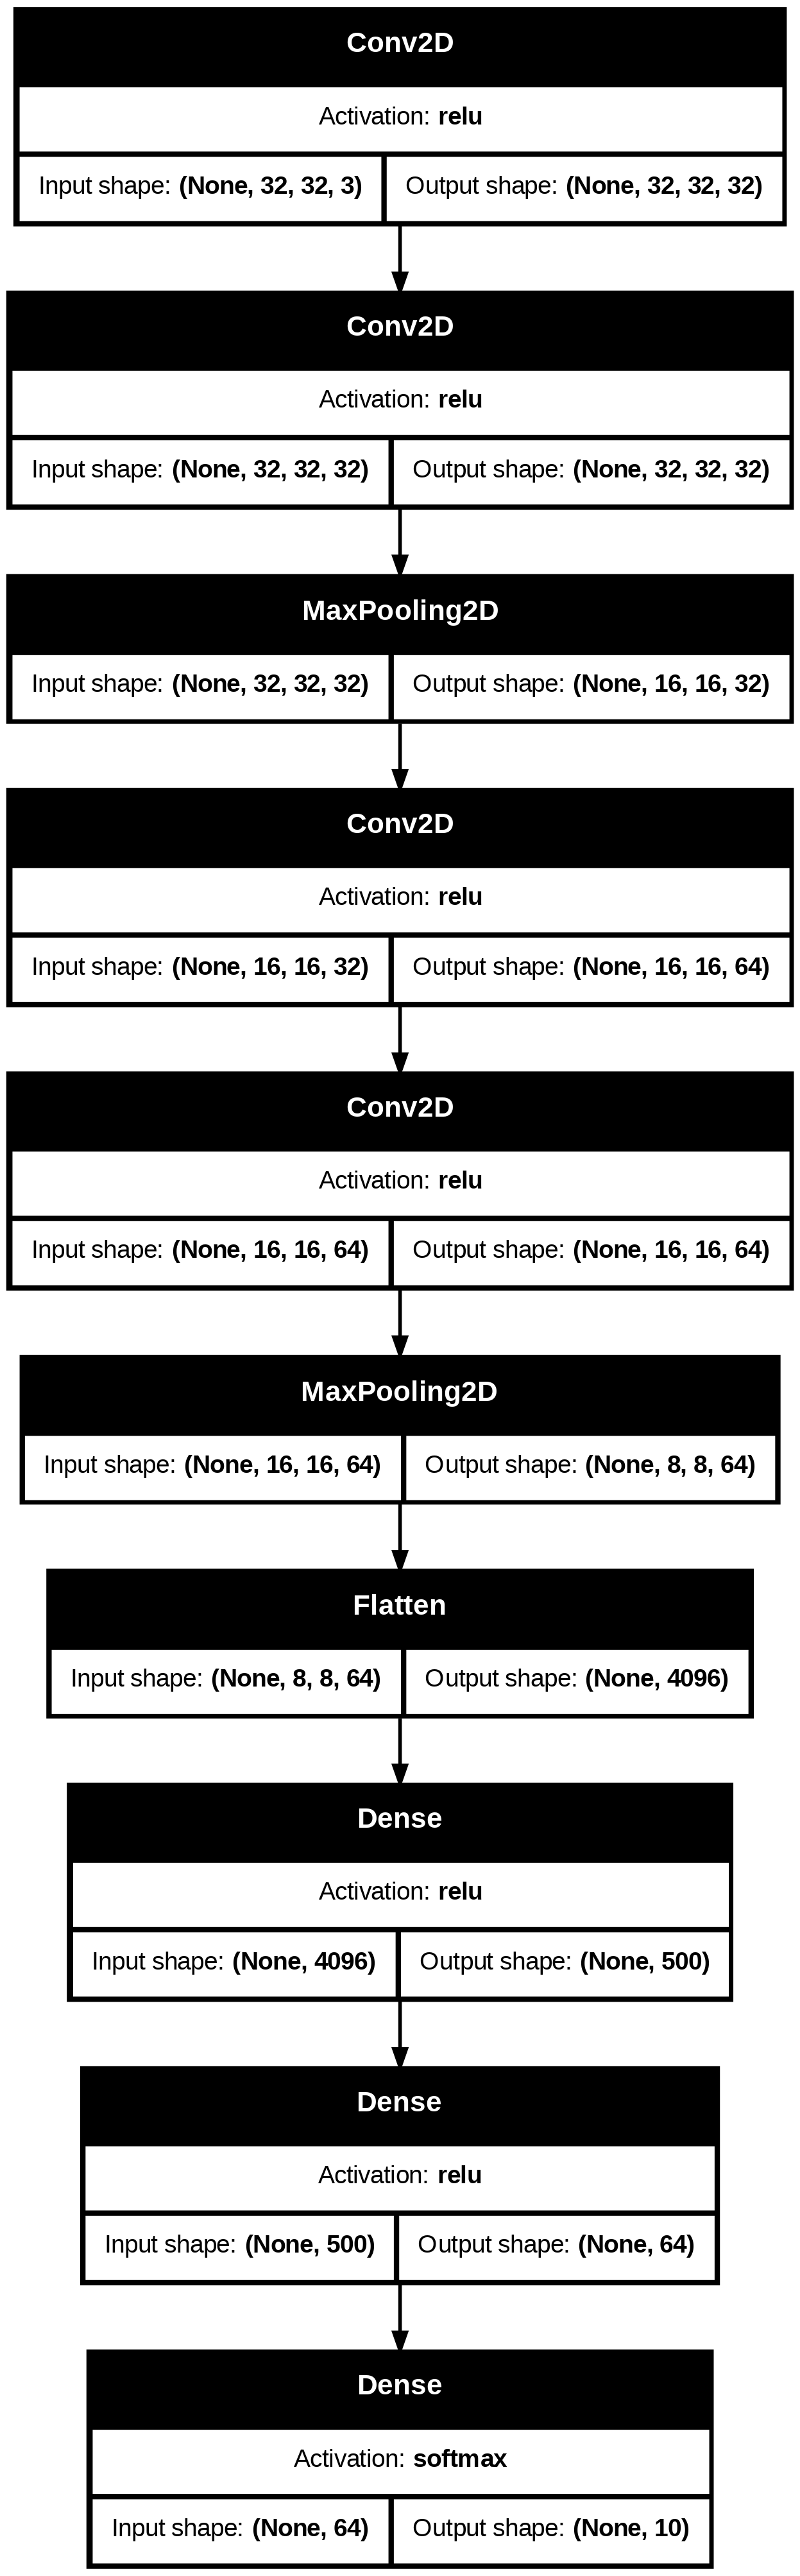

In [25]:
def cnn_model(input_shape=(32,32,3), conv_units = (32,64)):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(500, activation='relu'))
  model.add(Dense(64, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn_model(conv_units = (32, 64))
model.summary()
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
250/250 - 7s - 30ms/step - accuracy: 0.4392 - loss: 1.5451 - val_accuracy: 0.5676 - val_loss: 1.2283
Epoch 2/20
250/250 - 1s - 5ms/step - accuracy: 0.6205 - loss: 1.0724 - val_accuracy: 0.6364 - val_loss: 1.0329
Epoch 3/20
250/250 - 1s - 5ms/step - accuracy: 0.7000 - loss: 0.8527 - val_accuracy: 0.6853 - val_loss: 0.8983
Epoch 4/20
250/250 - 1s - 5ms/step - accuracy: 0.7514 - loss: 0.7116 - val_accuracy: 0.7257 - val_loss: 0.7933
Epoch 5/20
250/250 - 1s - 5ms/step - accuracy: 0.7958 - loss: 0.5812 - val_accuracy: 0.7248 - val_loss: 0.8002
Epoch 6/20
250/250 - 1s - 5ms/step - accuracy: 0.8349 - loss: 0.4748 - val_accuracy: 0.7407 - val_loss: 0.7921
Epoch 7/20
250/250 - 1s - 5ms/step - accuracy: 0.8753 - loss: 0.3591 - val_accuracy: 0.7411 - val_loss: 0.8142
Epoch 8/20
250/250 - 1s - 5ms/step - accuracy: 0.9132 - loss: 0.2527 - val_accuracy: 0.7368 - val_loss: 0.9612
Epoch 9/20
250/250 - 1s - 5ms/step - accuracy: 0.9421 - loss: 0.1680 - val_accuracy: 0.7401 - val_loss: 1.0731


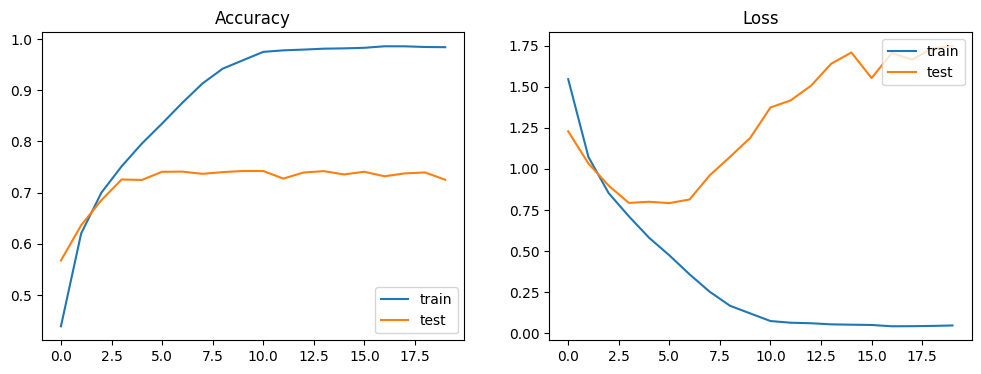

In [26]:
opt = tf.keras.optimizers.Adam()
model = cnn_model()

model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  20,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print_best_metrics(history.history)
plot_results(history)

## Additional Kernel and Back-to-Back Configuration Variants

These runs use different dense-layer sizes, convolution filter settings, and training durations
from the preceding architecture experiments.

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_52 (Conv2D)              │ (None, 32, 32, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 16, 16, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 32)             │       131,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,834 (647.79 KB)

 Trainable params: 165,834 (647.79 KB)

 Non-trainable params: 0 (0.00 B)

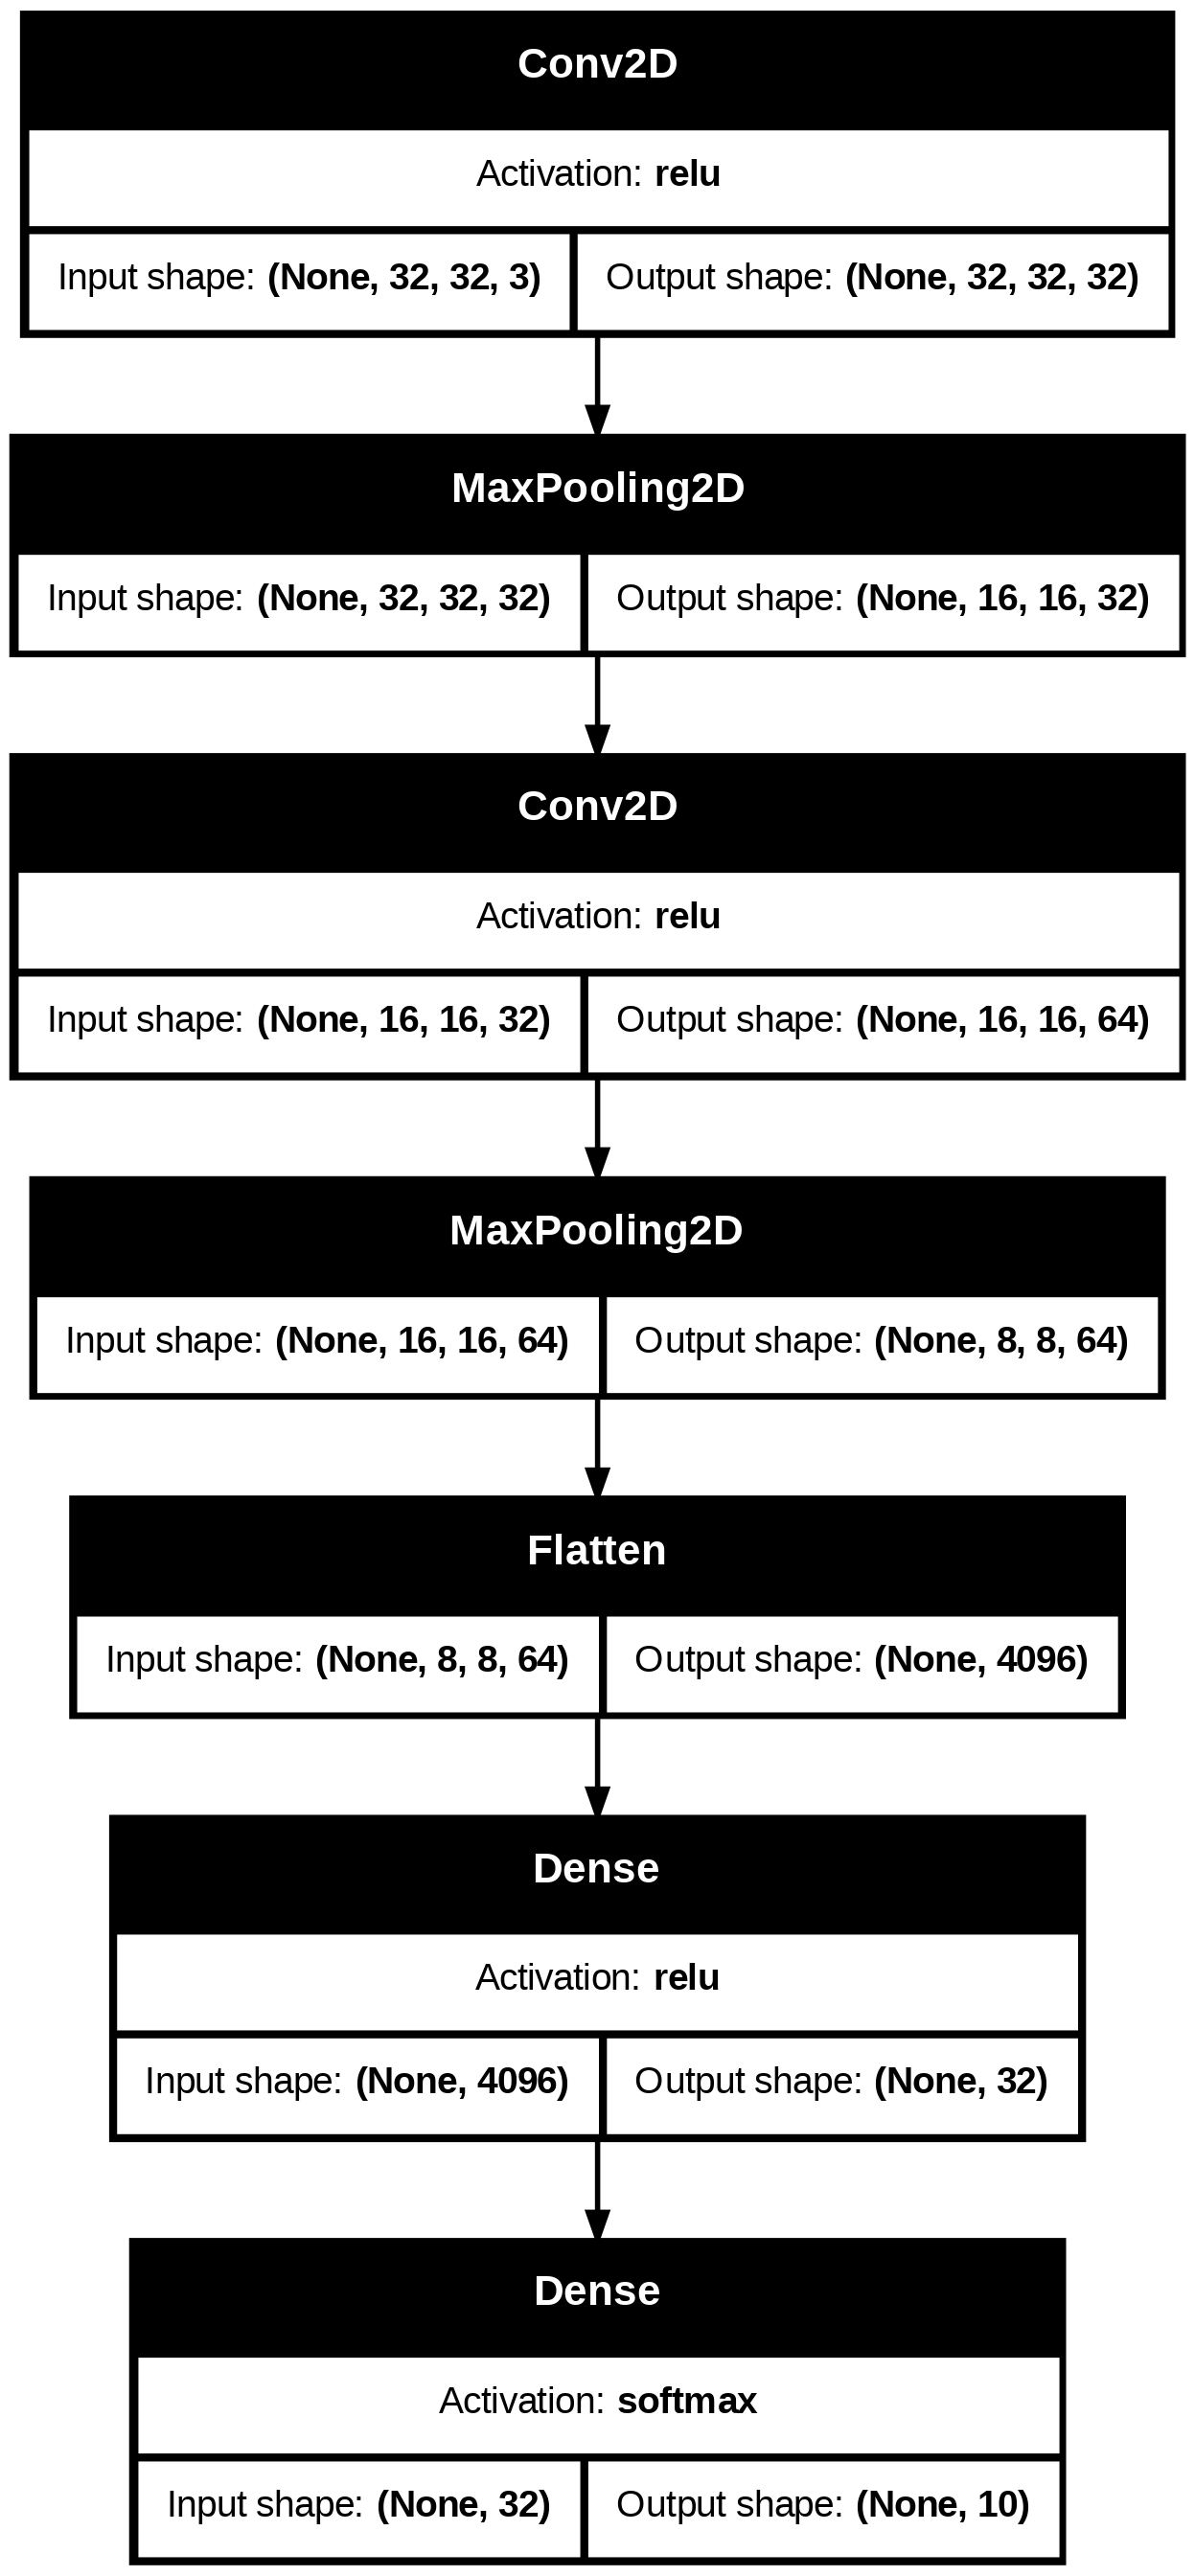

In [27]:
def cnn_model(input_shape=(32,32,3), conv_units = (32,64)):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(4, 4), input_shape=input_shape, padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(4, 4),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(32, activation='relu'))  #increasing the nodes of the dense layer
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn_model()
model.summary()
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
250/250 - 6s - 24ms/step - accuracy: 0.3650 - loss: 1.7326 - val_accuracy: 0.4852 - val_loss: 1.4269
Epoch 2/40
250/250 - 1s - 4ms/step - accuracy: 0.5205 - loss: 1.3436 - val_accuracy: 0.5392 - val_loss: 1.2720
Epoch 3/40
250/250 - 1s - 4ms/step - accuracy: 0.5825 - loss: 1.1844 - val_accuracy: 0.5757 - val_loss: 1.1844
Epoch 4/40
250/250 - 1s - 4ms/step - accuracy: 0.6229 - loss: 1.0780 - val_accuracy: 0.6261 - val_loss: 1.0636
Epoch 5/40
250/250 - 1s - 4ms/step - accuracy: 0.6533 - loss: 0.9987 - val_accuracy: 0.6461 - val_loss: 1.0194
Epoch 6/40
250/250 - 1s - 4ms/step - accuracy: 0.6723 - loss: 0.9442 - val_accuracy: 0.6612 - val_loss: 0.9928
Epoch 7/40
250/250 - 1s - 4ms/step - accuracy: 0.6867 - loss: 0.9046 - val_accuracy: 0.6693 - val_loss: 0.9680
Epoch 8/40
250/250 - 1s - 4ms/step - accuracy: 0.6982 - loss: 0.8720 - val_accuracy: 0.6635 - val_loss: 0.9658
Epoch 9/40
250/250 - 1s - 4ms/step - accuracy: 0.7133 - loss: 0.8338 - val_accuracy: 0.6779 - val_loss: 0.9416


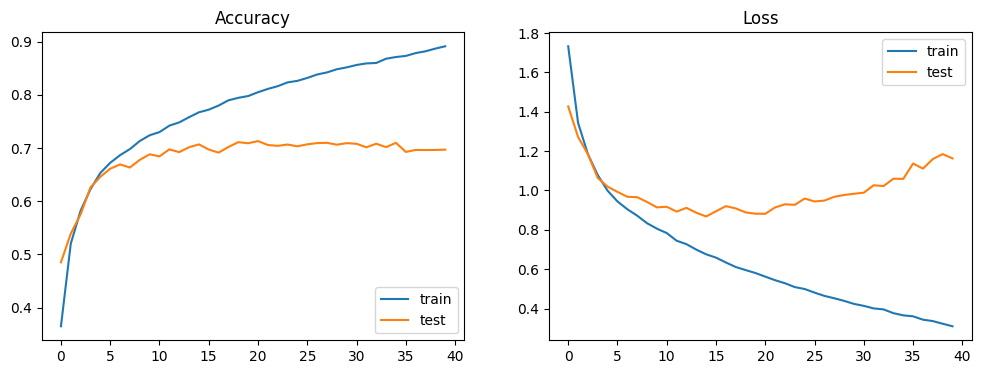

In [28]:
opt = tf.keras.optimizers.Adam()
model = cnn_model(conv_units = (32,64))

model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  40,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print_best_metrics(history.history)
plot_results(history)

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_56 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 32)             │        65,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,538 (369.29 KB)

 Trainable params: 94,538 (369.29 KB)

 Non-trainable params: 0 (0.00 B)

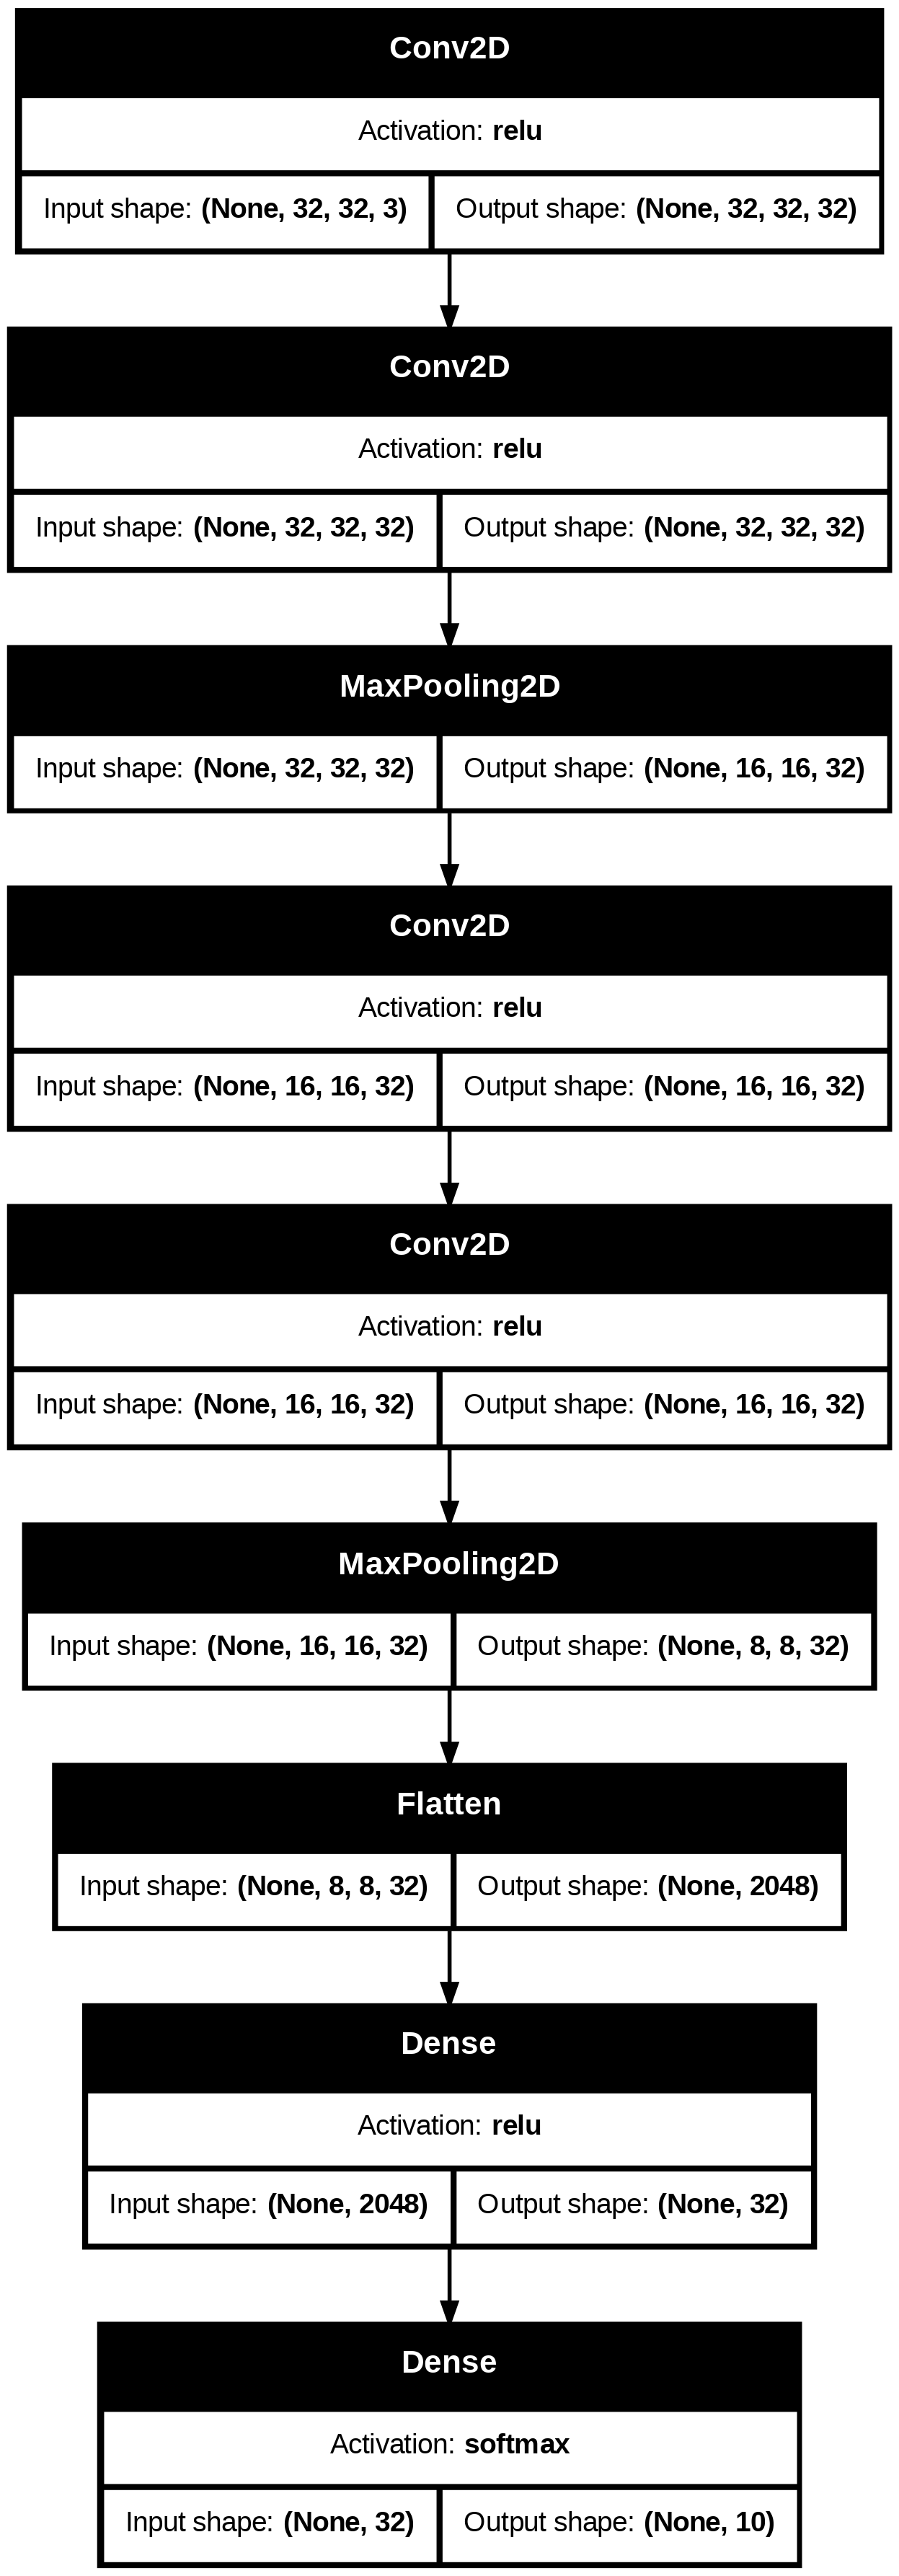

In [29]:
def cnn_model(input_shape=(32,32,3), conv_units = (32,32)):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(32, activation='relu'))  #increasing the nodes of the dense layer
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn_model()
model.summary()
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
250/250 - 6s - 23ms/step - accuracy: 0.3803 - loss: 1.7044 - val_accuracy: 0.4955 - val_loss: 1.4065
Epoch 2/40
250/250 - 1s - 5ms/step - accuracy: 0.5318 - loss: 1.3164 - val_accuracy: 0.5704 - val_loss: 1.2241
Epoch 3/40
250/250 - 1s - 5ms/step - accuracy: 0.5936 - loss: 1.1461 - val_accuracy: 0.6044 - val_loss: 1.1219
Epoch 4/40
250/250 - 1s - 5ms/step - accuracy: 0.6380 - loss: 1.0295 - val_accuracy: 0.6472 - val_loss: 1.0019
Epoch 5/40
250/250 - 1s - 5ms/step - accuracy: 0.6678 - loss: 0.9538 - val_accuracy: 0.6598 - val_loss: 0.9710
Epoch 6/40
250/250 - 1s - 5ms/step - accuracy: 0.6895 - loss: 0.8945 - val_accuracy: 0.6619 - val_loss: 0.9793
Epoch 7/40
250/250 - 1s - 5ms/step - accuracy: 0.7046 - loss: 0.8438 - val_accuracy: 0.6876 - val_loss: 0.9121
Epoch 8/40
250/250 - 1s - 5ms/step - accuracy: 0.7204 - loss: 0.8013 - val_accuracy: 0.6892 - val_loss: 0.9034
Epoch 9/40
250/250 - 1s - 5ms/step - accuracy: 0.7346 - loss: 0.7652 - val_accuracy: 0.6959 - val_loss: 0.8927


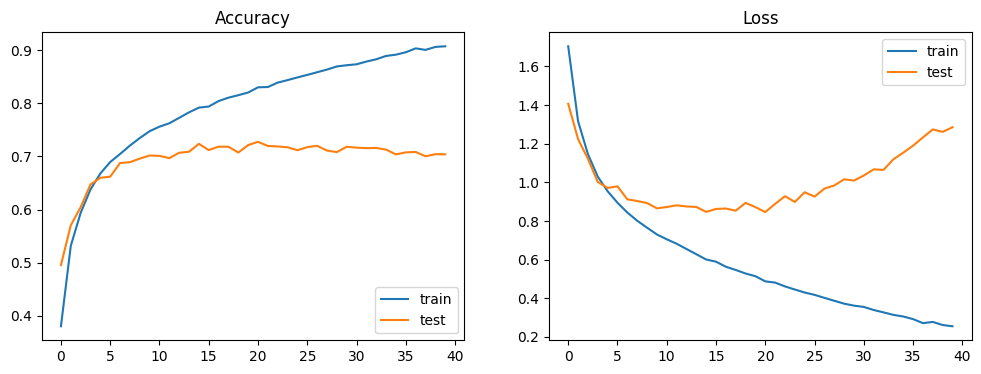

In [30]:
opt = tf.keras.optimizers.Adam()
model = cnn_model(conv_units = (32,32))

model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs =  40,
    batch_size = 200,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print_best_metrics(history.history)
plot_results(history)

## Extended Architecture Study: Pooling, Strides, and Depth

## Strided Convolution Instead of Max Pooling

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_64 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 16, 16, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_66 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 8, 8, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_21 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 302,826 (1.16 MB)

 Trainable params: 302,826 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

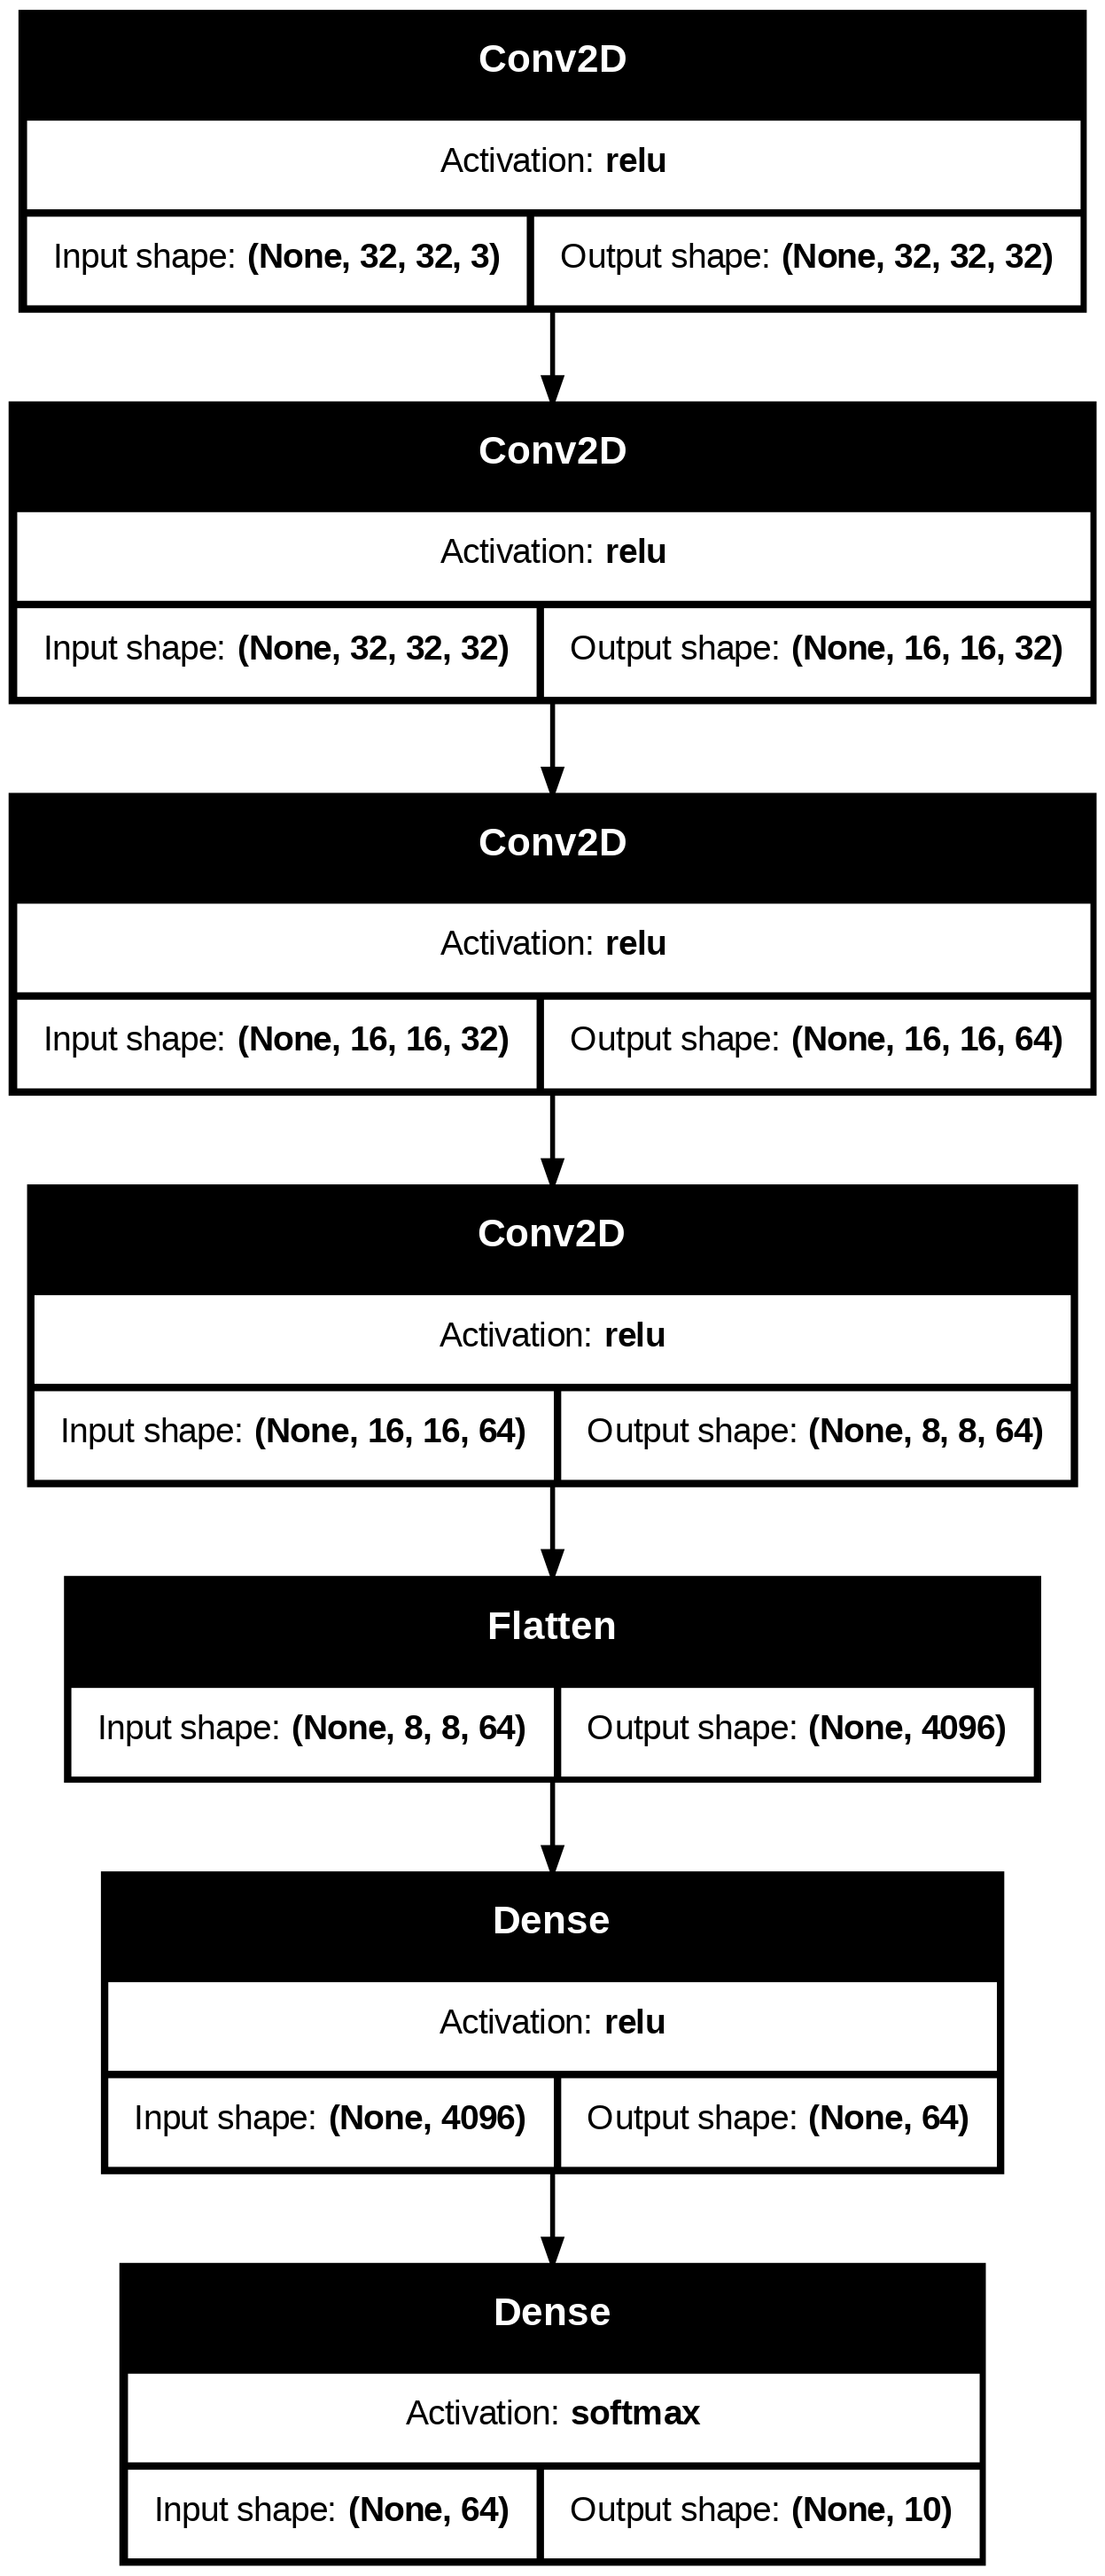

In [31]:
def cnn_model(input_shape=(32,32,3), conv_units = (32,64)):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(Conv2D(conv_units[0], kernel_size=(2, 2), strides =(2,2), padding='same', activation="relu"))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(2, 2),  strides =(2,2), padding='same', activation="relu"))
  model.add(Flatten())
  model.add(Dense(64, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn_model()
model.summary()
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
500/500 - 8s - 16ms/step - accuracy: 0.4368 - loss: 1.5670 - val_accuracy: 0.5277 - val_loss: 1.3121
Epoch 2/40
500/500 - 2s - 3ms/step - accuracy: 0.5789 - loss: 1.1844 - val_accuracy: 0.6017 - val_loss: 1.1168
Epoch 3/40
500/500 - 2s - 3ms/step - accuracy: 0.6351 - loss: 1.0303 - val_accuracy: 0.6342 - val_loss: 1.0279
Epoch 4/40
500/500 - 2s - 3ms/step - accuracy: 0.6733 - loss: 0.9242 - val_accuracy: 0.6543 - val_loss: 0.9755
Epoch 5/40
500/500 - 2s - 3ms/step - accuracy: 0.7062 - loss: 0.8330 - val_accuracy: 0.6748 - val_loss: 0.9192
Epoch 6/40
500/500 - 2s - 3ms/step - accuracy: 0.7320 - loss: 0.7604 - val_accuracy: 0.6843 - val_loss: 0.9108
Epoch 7/40
500/500 - 2s - 3ms/step - accuracy: 0.7588 - loss: 0.6908 - val_accuracy: 0.6870 - val_loss: 0.8932
Epoch 8/40
500/500 - 2s - 3ms/step - accuracy: 0.7785 - loss: 0.6334 - val_accuracy: 0.6874 - val_loss: 0.9096
Epoch 9/40
500/500 - 2s - 3ms/step - accuracy: 0.8007 - loss: 0.5693 - val_accuracy: 0.6953 - val_loss: 0.9519


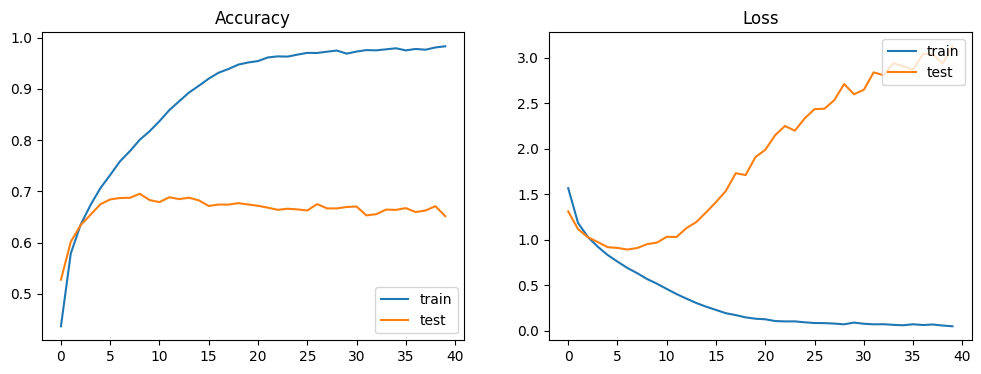

In [32]:
for opt in [tf.keras.optimizers.Adam()]:
  model = cnn_model(input_shape=x_train.shape[1:])

  model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

  history = model.fit(
    x_train, y_train,
    epochs =  40,
    batch_size=100,
    verbose = 2,
    validation_data=(x_test, y_test),
  )

  print_best_metrics(history.history)
  plot_results(history)

## Increasing Network Depth

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_72 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_74 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_23 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

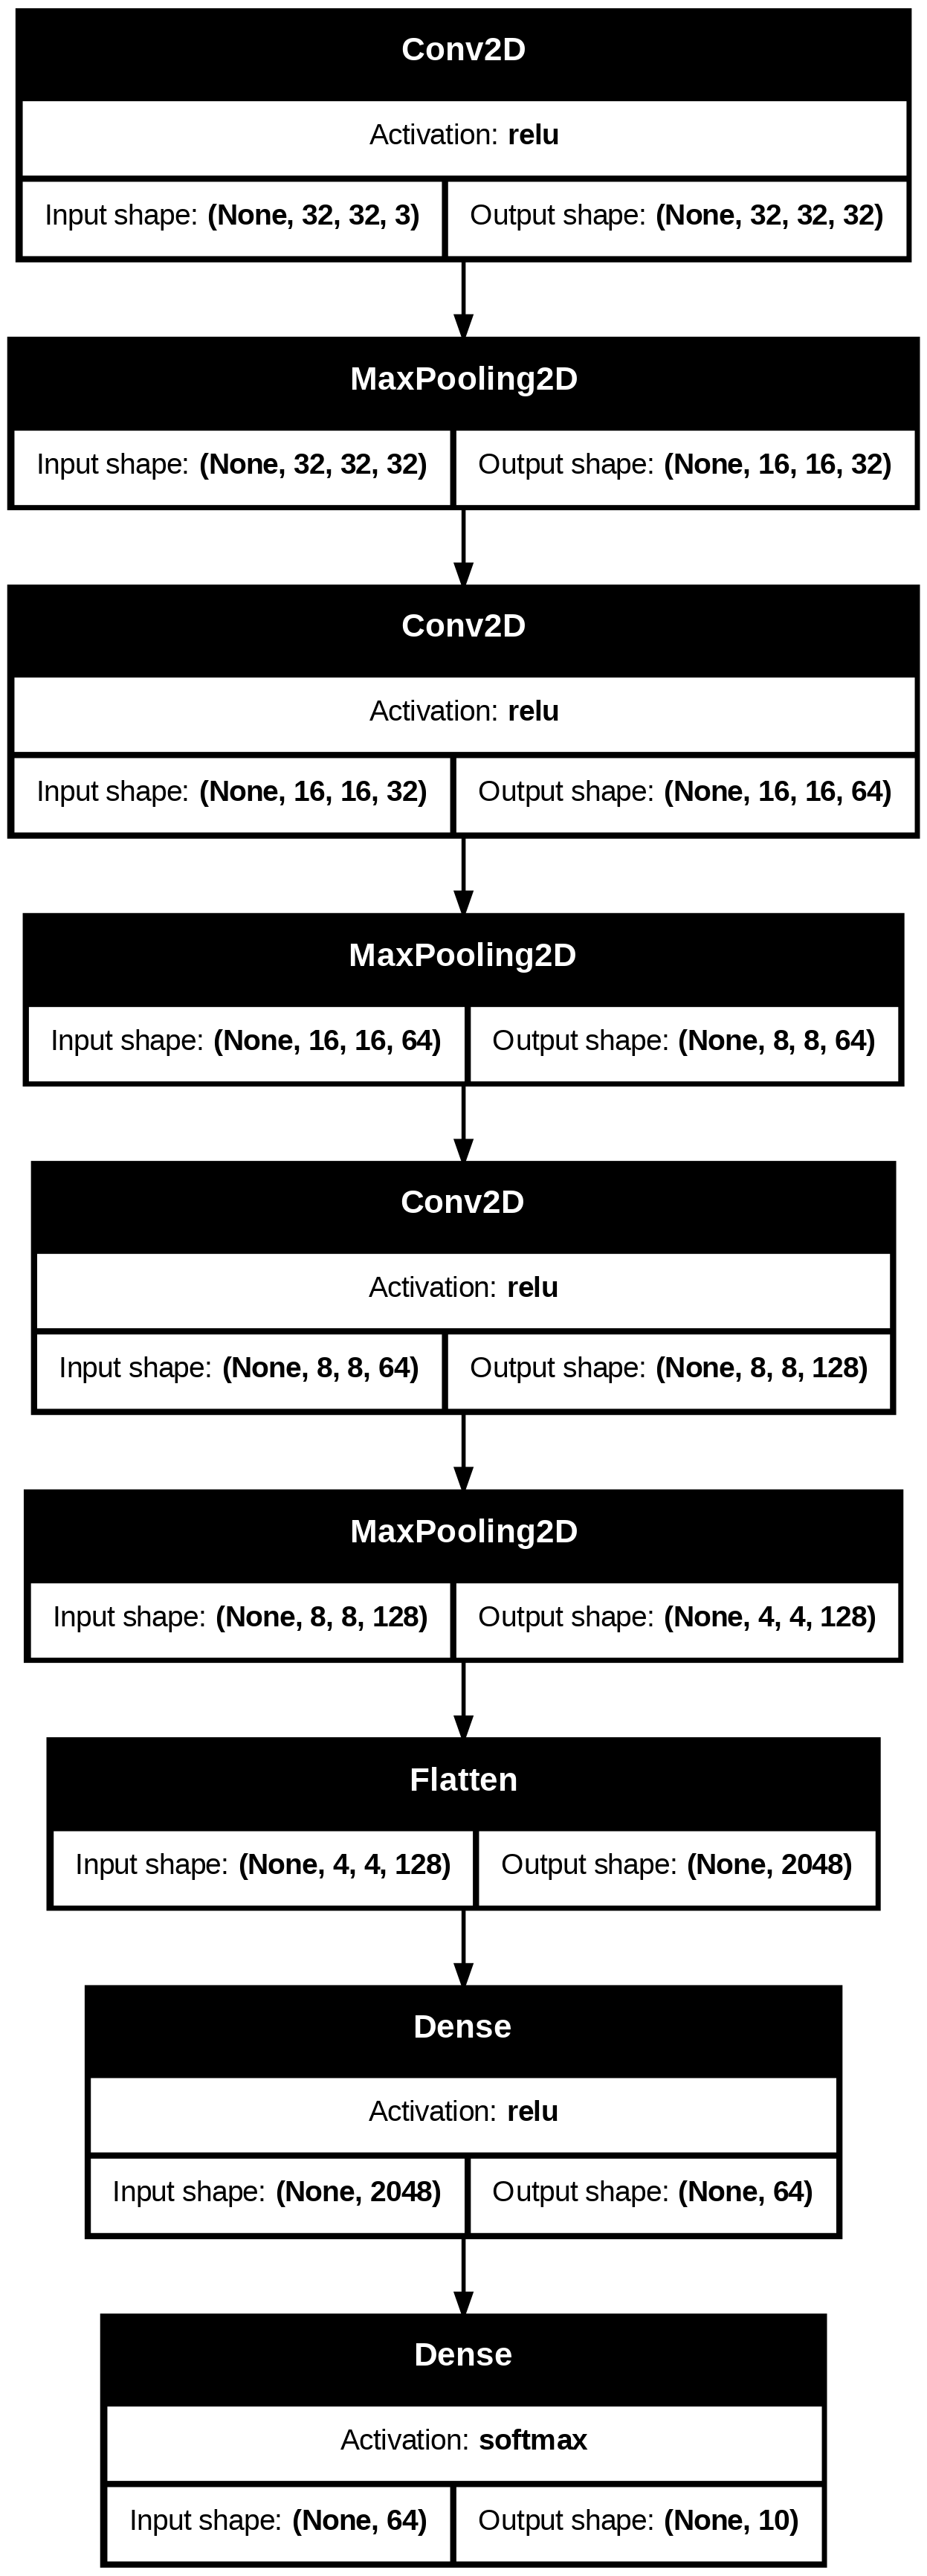

In [33]:
def cnn_model(input_shape=(32,32,3), conv_units = (32,64)):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(64, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn_model(conv_units = (32,64,128))
model.summary()
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


The highest training accuracy was 0.9803 obtained in epoch 38
The final training accuracy was 0.9757
The highest validation accuracy was 0.7556 obtained in epoch 11
The final validation accuracy was 0.7235
The lowest training loss was 0.0563 obtained in epoch 38
The final training loss was 0.0690
The lowest validation loss was 0.7664 obtained in epoch 9
The final validation loss was 2.2017


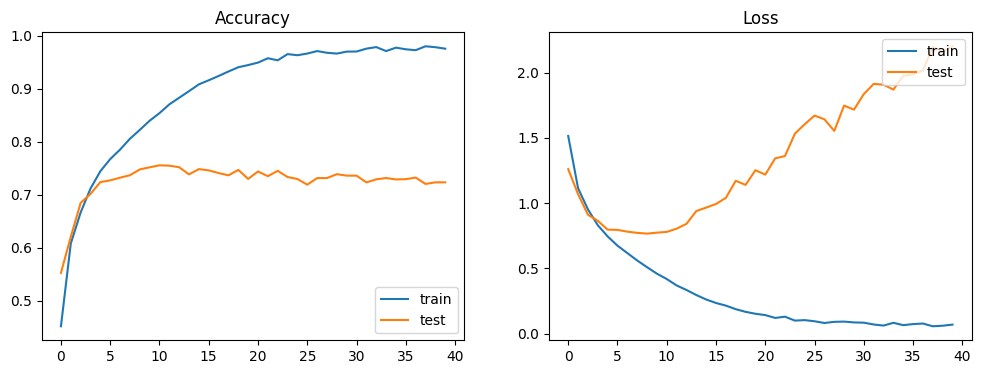

In [34]:
for opt in [tf.keras.optimizers.SGD(momentum=0.9), tf.keras.optimizers.Adam()][1:]:
  model = cnn_model(conv_units = (32,64,128))
  model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

  history = model.fit(
    x_train, y_train,
    epochs =  40,
    batch_size=100,
    verbose = 0,
    validation_data=(x_test, y_test),
  )

  print_best_metrics(history.history)
  plot_results(history)

The highest training accuracy was 0.9872 obtained in epoch 37
The final training accuracy was 0.9856
The highest validation accuracy was 0.7374 obtained in epoch 40
The final validation accuracy was 0.7374
The lowest training loss was 0.0385 obtained in epoch 37
The final training loss was 0.0424
The lowest validation loss was 0.8296 obtained in epoch 7
The final validation loss was 2.0886


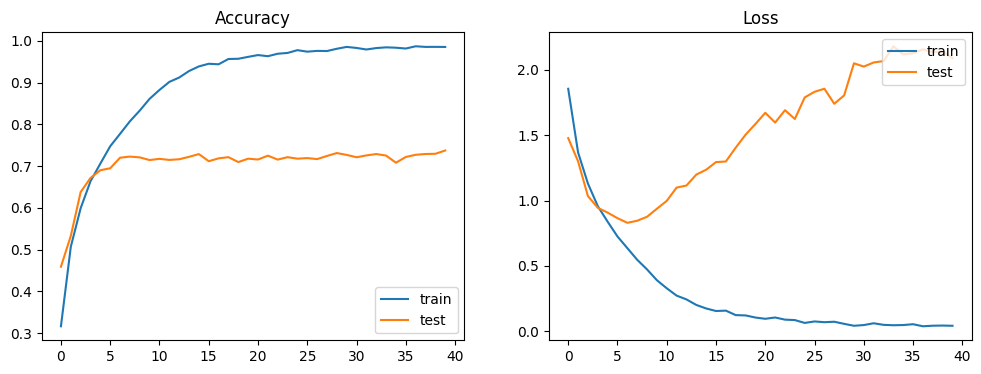

The highest training accuracy was 0.9849 obtained in epoch 35
The final training accuracy was 0.9820
The highest validation accuracy was 0.7433 obtained in epoch 9
The final validation accuracy was 0.7323
The lowest training loss was 0.0438 obtained in epoch 35
The final training loss was 0.0542
The lowest validation loss was 0.7637 obtained in epoch 5
The final validation loss was 2.1630


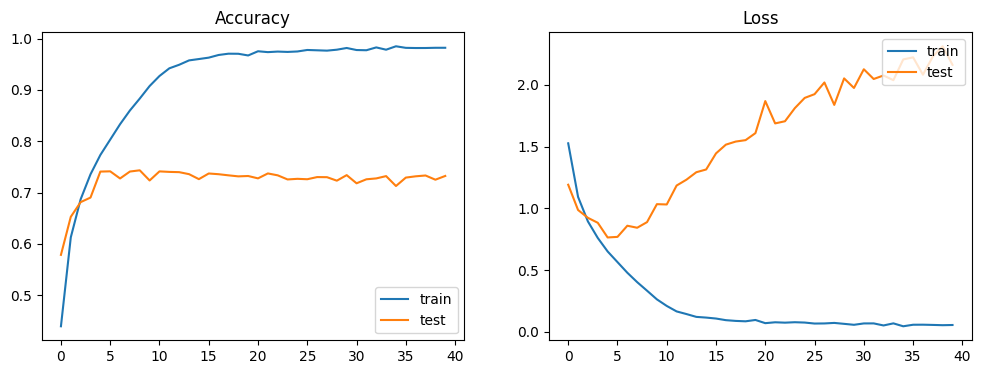

In [35]:
for opt in [tf.keras.optimizers.SGD(momentum=0.9), tf.keras.optimizers.Adam()]:
  model = cnn_model(conv_units = (32,64,128,256))
  model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

  history = model.fit(
    x_train, y_train,
    epochs =  40,
    batch_size=100,
    verbose = 0,
    validation_data=(x_test, y_test),
  )

  print_best_metrics(history.history)
  plot_results(history)

### Additional Depth Optimizer Variant

This configuration evaluates the deeper `(32, 64, 128)` convolutional network with both SGD
with momentum and Adam.

The highest training accuracy was 0.9818 obtained in epoch 37
The final training accuracy was 0.9794
The highest validation accuracy was 0.7294 obtained in epoch 12
The final validation accuracy was 0.7192
The lowest training loss was 0.0540 obtained in epoch 37
The final training loss was 0.0619
The lowest validation loss was 0.8570 obtained in epoch 8
The final validation loss was 2.3533


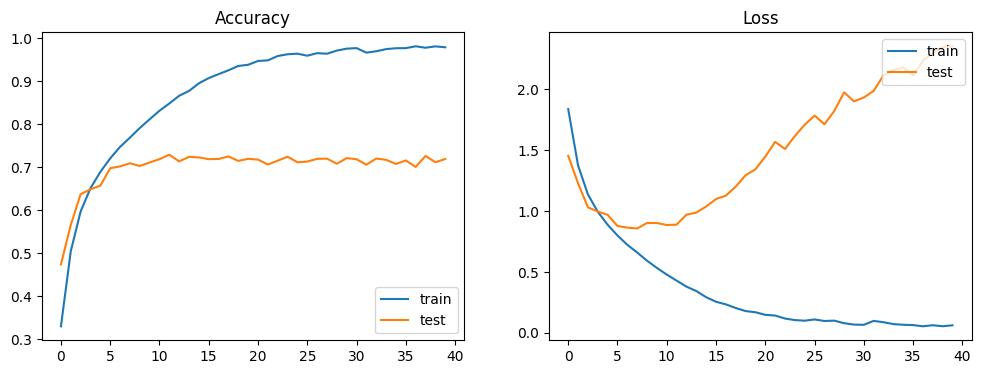

The highest training accuracy was 0.9772 obtained in epoch 37
The final training accuracy was 0.9769
The highest validation accuracy was 0.7540 obtained in epoch 10
The final validation accuracy was 0.7353
The lowest training loss was 0.0657 obtained in epoch 40
The final training loss was 0.0657
The lowest validation loss was 0.7742 obtained in epoch 8
The final validation loss was 2.0121


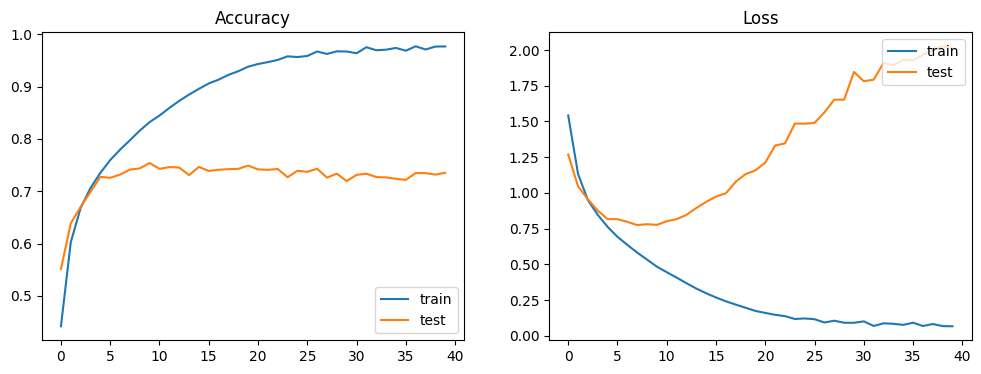

In [36]:
for opt in [tf.keras.optimizers.SGD(momentum=0.9), tf.keras.optimizers.Adam()]:
  model = cnn_model(conv_units = (32,64,128))
  model.compile(optimizer=opt, loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])

  history = model.fit(
    x_train, y_train,
    epochs =  40,
    batch_size=100,
    verbose = 0,
    validation_data=(x_test, y_test),
  )

  print_best_metrics(history.history)
  plot_results(history)